<a href="https://colab.research.google.com/github/zfifteen/unified-framework/blob/main/notesbooks/2025_08_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import mpmath
import time

mpmath.mp.dps = 50

def base_pnt_prime(k):
    k = mpmath.mpf(k)
    ln_k = mpmath.log(k)
    ln_ln_k = mpmath.log(ln_k)
    return k * (ln_k + ln_ln_k - 1 + (ln_ln_k - 2) / ln_k)

def d_term(k):
    p_pnt = base_pnt_prime(k)
    return (mpmath.log(p_pnt) / mpmath.exp(4)) ** 2

def e_term(k):
    p_pnt = base_pnt_prime(k)
    return p_pnt ** mpmath.mpf('-1/3')

def z5d_prime(k, c: float = -0.00247, k_star: float = 0.04449):
    c = mpmath.mpf(c)
    k_star = mpmath.mpf(k_star)
    p_pnt = base_pnt_prime(k)
    return p_pnt + c * d_term(k) * p_pnt + k_star * e_term(k) * p_pnt

def pase_prime(k):
    k = mpmath.mpf(k)
    return k / mpmath.log(k)

def li_prime(k):
    k = mpmath.mpf(k)
    return mpmath.li(k)

# Example small benchmarks
ks_small = [1000, 10000, 100000, 1000000, 10000000]
true_primes_small = [7919, 104729, 1299709, 15485863, 179424673]
preds = [z5d_prime(k) for k in ks_small]
for k, pred, true in zip(ks_small, preds, true_primes_small):
    error = abs(pred - true) / true * 100
    print(f"k={k}: Predicted={float(pred):.2f}, True={true}, Error={float(error):.4f}%")

# Large benchmarks with known true values
ks = [10**5, 10**6, 10**7, 10**8, 10**9, 10**10, 10**11, 10**12]
trues = [mpmath.mpf(t) for t in [1299709, 15485863, 179424673, 2038074743, 22801763489, 252097800623, 2760624443953, 29996224275833]]

for k, true in zip(ks, trues):
    start = time.time()
    pred_z = z5d_prime(k)
    time_z = time.time() - start
    err_z = abs(pred_z - true) / true * 100

    start = time.time()
    pred_p = pase_prime(k)
    time_p = time.time() - start
    err_p = abs(pred_p - true) / true * 100

    start = time.time()
    pred_l = li_prime(k)
    time_l = time.time() - start
    err_l = abs(pred_l - true) / true * 100

    print(f"k={k}: Z5D={float(pred_z)}, Error={float(err_z):.4f}%, Time={time_z:.4f}s")
    print(f" PASE={float(pred_p)}, Error={float(err_p):.4f}%, Time={time_p:.4f}s")
    print(f" LI={float(pred_l)}, Error={float(err_l):.4f}%, Time={time_l:.4f}s")

k=1000: Predicted=7847.67, True=7919, Error=0.9007%
k=10000: Predicted=104633.05, True=104729, Error=0.0916%
k=100000: Predicted=1299807.93, True=1299709, Error=0.0076%
k=1000000: Predicted=15485845.91, True=15485863, Error=0.0001%
k=10000000: Predicted=179424717.41, True=179424673, Error=0.0000%
k=100000: Z5D=1299807.930785591, Error=0.0076%, Time=0.0003s
 PASE=8685.889638065037, Error=99.3317%, Time=0.0000s
 LI=9629.809001050799, Error=99.2591%, Time=0.0008s
k=1000000: Z5D=15485845.912544638, Error=0.0001%, Time=0.0003s
 PASE=72382.41365054197, Error=99.5326%, Time=0.0000s
 LI=78627.54915946219, Error=99.4923%, Time=0.0002s
k=10000000: Z5D=179424717.4075586, Error=0.0000%, Time=0.0003s
 PASE=620420.6884332169, Error=99.6542%, Time=0.0000s
 LI=664918.405048569, Error=99.6294%, Time=0.0002s
k=100000000: Z5D=2037669907.2400668, Error=0.0199%, Time=0.0004s
 PASE=5428681.023790648, Error=99.7336%, Time=0.0000s
 LI=5762209.375448031, Error=99.7173%, Time=0.0002s
k=1000000000: Z5D=227938955

# Task
Generate a detailed statistical analysis suite with numerous 2D and 3D plots to analyze the output of the prime number estimation code in cell 1, focusing on error, execution time, and the relationship between predicted and true prime numbers across different estimation methods and values of k.

## Data preparation

### Subtask:
Organize the results from the prime estimation functions (k, true prime, predictions, errors, and times) into a structured format suitable for plotting, such as a pandas DataFrame.


**Reasoning**:
Import pandas and initialize lists to store the data for the DataFrame.



In [2]:
import pandas as pd

ks_list = []
true_primes_list = []
z5d_predictions = []
z5d_errors = []
z5d_times = []
pase_predictions = []
pase_errors = []
pase_times = []
li_predictions = []
li_errors = []
li_times = []

**Reasoning**:
Iterate through the k and true values, calculate predictions, errors, and times, and append them to the respective lists.



In [3]:
for k, true in zip(ks, trues):
    ks_list.append(float(k))
    true_primes_list.append(float(true))

    start = time.time()
    pred_z = z5d_prime(k)
    time_z = time.time() - start
    err_z = abs(pred_z - true) / true * 100
    z5d_predictions.append(float(pred_z))
    z5d_errors.append(float(err_z))
    z5d_times.append(time_z)

    start = time.time()
    pred_p = pase_prime(k)
    time_p = time.time() - start
    err_p = abs(pred_p - true) / true * 100
    pase_predictions.append(float(pred_p))
    pase_errors.append(float(err_p))
    pase_times.append(time_p)

    start = time.time()
    pred_l = li_prime(k)
    time_l = time.time() - start
    err_l = abs(pred_l - true) / true * 100
    li_predictions.append(float(pred_l))
    li_errors.append(float(err_l))
    li_times.append(time_l)

**Reasoning**:
Create a pandas DataFrame from the collected lists and display its head and info.



In [4]:
results_df = pd.DataFrame({
    'k': ks_list,
    'true_prime': true_primes_list,
    'z5d_prediction': z5d_predictions,
    'z5d_error': z5d_errors,
    'z5d_time': z5d_times,
    'pase_prediction': pase_predictions,
    'pase_error': pase_errors,
    'pase_time': pase_times,
    'li_prediction': li_predictions,
    'li_error': li_errors,
    'li_time': li_times
})

display(results_df.head())
results_df.info()

,k,true_prime,z5d_prediction,z5d_error,z5d_time,pase_prediction,pase_error,pase_time,li_prediction,li_error,li_time
0,1.000000e+05,1.299709e+06,1.299808e+06,0.007612,0.002299,8.685890e+03,99.331705,0.000028,9.629809e+03,99.259080,0.000170
1,1.000000e+06,1.548586e+07,1.548585e+07,0.000110,0.000297,7.238241e+04,99.532590,0.000024,7.862755e+04,99.492262,0.000165
2,1.000000e+07,1.794247e+08,1.794247e+08,0.000025,0.000295,6.204207e+05,99.654217,0.000025,6.649184e+05,99.629416,0.000170
3,1.000000e+08,2.038075e+09,2.037670e+09,0.019864,0.000259,5.428681e+06,99.733637,0.000024,5.762209e+06,99.717272,0.000166
4,1.000000e+09,2.280176e+10,2.279390e+10,0.034506,0.000254,4.825494e+07,99.788372,0.000025,5.084923e+07,99.776994,0.000189


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   k                8 non-null      float64
 1   true_prime       8 non-null      float64
 2   z5d_prediction   8 non-null      float64
 3   z5d_error        8 non-null      float64
 4   z5d_time         8 non-null      float64
 5   pase_prediction  8 non-null      float64
 6   pase_error       8 non-null      float64
 7   pase_time        8 non-null      float64
 8   li_prediction    8 non-null      float64
 9   li_error         8 non-null      float64
 10  li_time          8 non-null      float64
dtypes: float64(11)
memory usage: 836.0 bytes


## 2d plotting - error analysis

### Subtask:
Generate 2D plots to visualize the percentage error of each estimation method against k. This could include separate plots for each method or a single plot comparing all three.


**Reasoning**:
Import the necessary libraries for plotting and create a single figure with a subplot to visualize the percentage error of each estimation method against k using a line plot with a logarithmic scale for the x-axis.



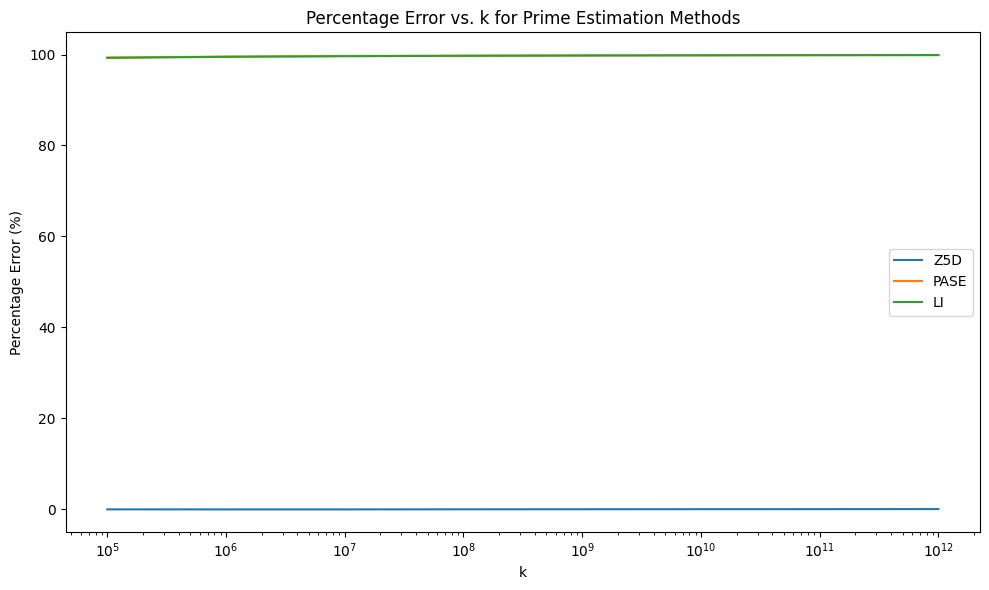

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=results_df, x='k', y='z5d_error', ax=ax, label='Z5D')
sns.lineplot(data=results_df, x='k', y='pase_error', ax=ax, label='PASE')
sns.lineplot(data=results_df, x='k', y='li_error', ax=ax, label='LI')

ax.set_xscale('log')
ax.set_xlabel('k')
ax.set_ylabel('Percentage Error (%)')
ax.set_title('Percentage Error vs. k for Prime Estimation Methods')
ax.legend()
plt.tight_layout()
plt.show()

## 2d plotting - time analysis

### Subtask:
Generate 2D plots to visualize the execution time of each estimation method against k. Similar to error analysis, this could be separate plots or a combined plot.


**Reasoning**:
Generate a 2D plot to visualize the execution time of each estimation method against k using the results_df DataFrame.



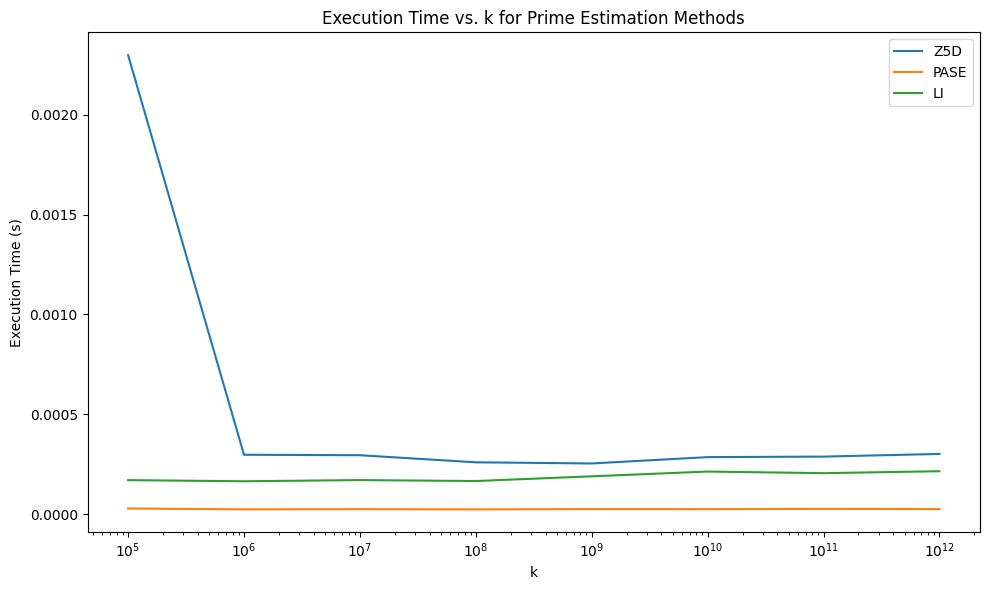

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=results_df, x='k', y='z5d_time', ax=ax, label='Z5D')
sns.lineplot(data=results_df, x='k', y='pase_time', ax=ax, label='PASE')
sns.lineplot(data=results_df, x='k', y='li_time', ax=ax, label='LI')

ax.set_xscale('log')
ax.set_xlabel('k')
ax.set_ylabel('Execution Time (s)')
ax.set_title('Execution Time vs. k for Prime Estimation Methods')
ax.legend()
plt.tight_layout()
plt.show()

## 2d plotting - predicted vs. true

### Subtask:
Generate 2D plots comparing the predicted prime number against the true prime number for each method.


**Reasoning**:
Generate scatter plots to compare predicted vs true prime numbers for each method, including a perfect prediction line and using logarithmic scales.



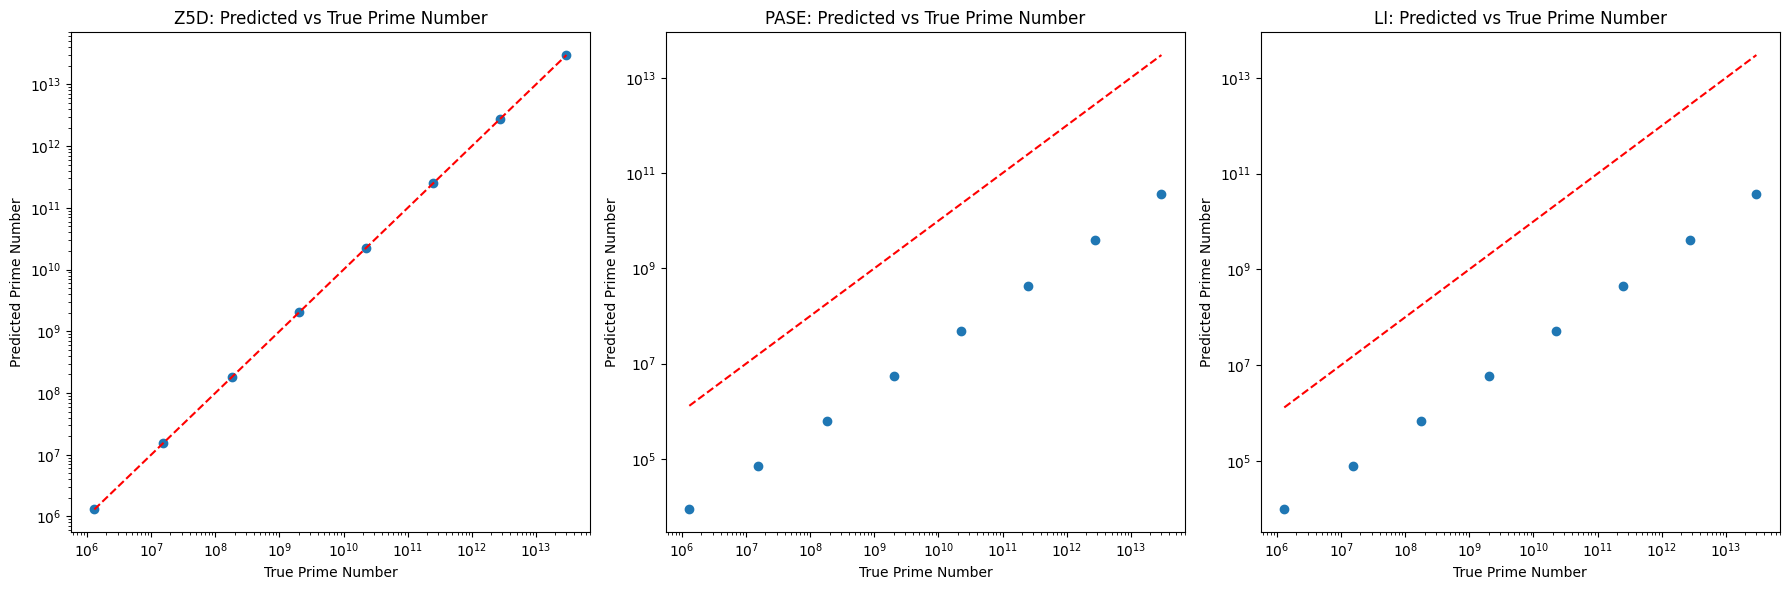

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Z5D Plot
axes[0].scatter(results_df['true_prime'], results_df['z5d_prediction'])
axes[0].plot(results_df['true_prime'], results_df['true_prime'], color='red', linestyle='--')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('True Prime Number')
axes[0].set_ylabel('Predicted Prime Number')
axes[0].set_title('Z5D: Predicted vs True Prime Number')

# PASE Plot
axes[1].scatter(results_df['true_prime'], results_df['pase_prediction'])
axes[1].plot(results_df['true_prime'], results_df['true_prime'], color='red', linestyle='--')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('True Prime Number')
axes[1].set_ylabel('Predicted Prime Number')
axes[1].set_title('PASE: Predicted vs True Prime Number')

# LI Plot
axes[2].scatter(results_df['true_prime'], results_df['li_prediction'])
axes[2].plot(results_df['true_prime'], results_df['true_prime'], color='red', linestyle='--')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_xlabel('True Prime Number')
axes[2].set_ylabel('Predicted Prime Number')
axes[2].set_title('LI: Predicted vs True Prime Number')

plt.tight_layout()
plt.show()

## 3d plotting - error and time

### Subtask:
Generate 3D plots to explore the relationship between k, error, and execution time for each method. This could involve plotting error and time on the z-axis against k on the x-axis and perhaps the method on the y-axis (if combining methods).


**Reasoning**:
Generate a 3D scatter plot for the Z5D method showing the relationship between k, error, and time.



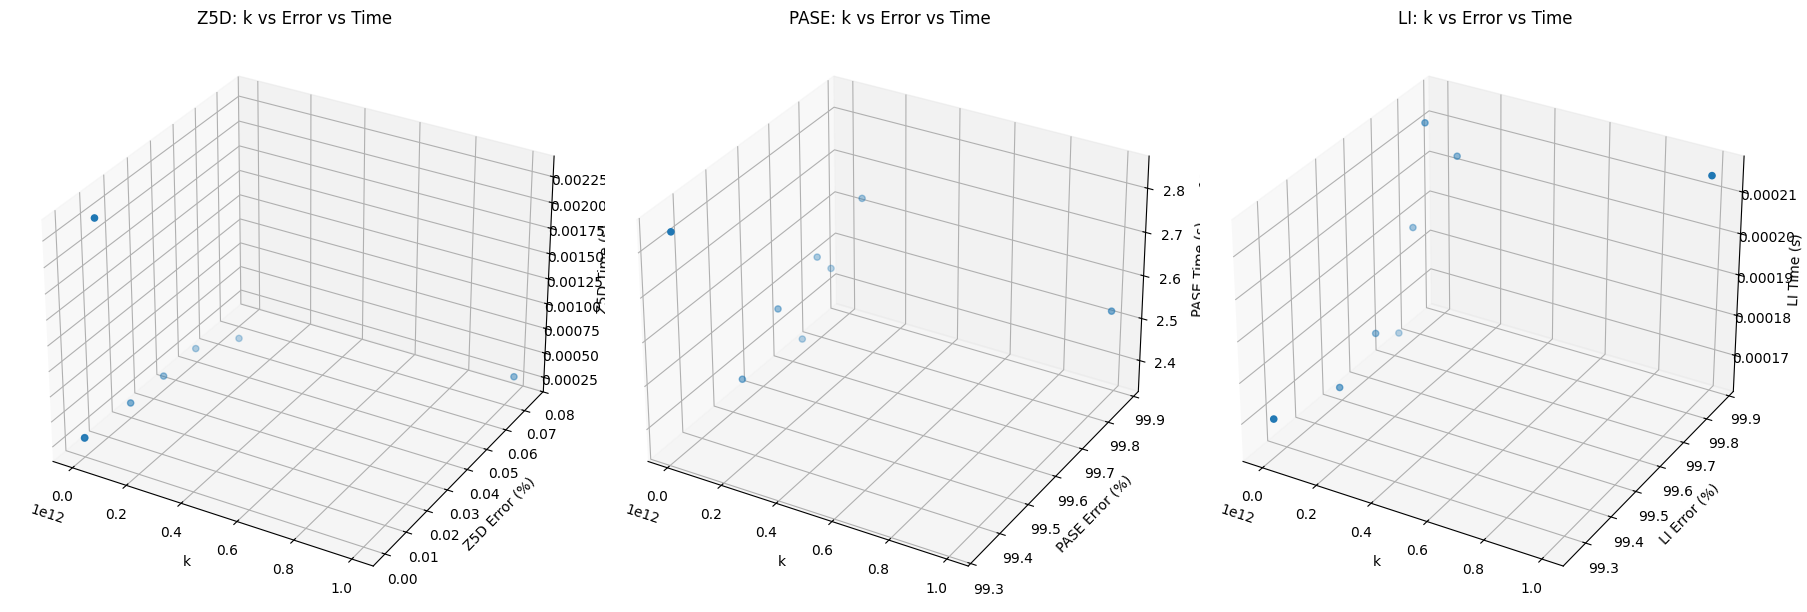

In [8]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 6))

# Z5D 3D plot
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(results_df['k'], results_df['z5d_error'], results_df['z5d_time'])
ax1.set_xlabel('k')
ax1.set_ylabel('Z5D Error (%)')
ax1.set_zlabel('Z5D Time (s)')
ax1.set_title('Z5D: k vs Error vs Time')

# PASE 3D plot
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(results_df['k'], results_df['pase_error'], results_df['pase_time'])
ax2.set_xlabel('k')
ax2.set_ylabel('PASE Error (%)')
ax2.set_zlabel('PASE Time (s)')
ax2.set_title('PASE: k vs Error vs Time')

# LI 3D plot
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(results_df['k'], results_df['li_error'], results_df['li_time'])
ax3.set_xlabel('k')
ax3.set_ylabel('LI Error (%)')
ax3.set_zlabel('LI Time (s)')
ax3.set_title('LI: k vs Error vs Time')

plt.tight_layout()
plt.show()

## 3d plotting - predicted, true, and k

### Subtask:
Generate 3D plots showing the relationship between k, the predicted prime, and the true prime.


**Reasoning**:
Generate the 3D plots showing the relationship between k, the predicted prime, and the true prime for each method as instructed.



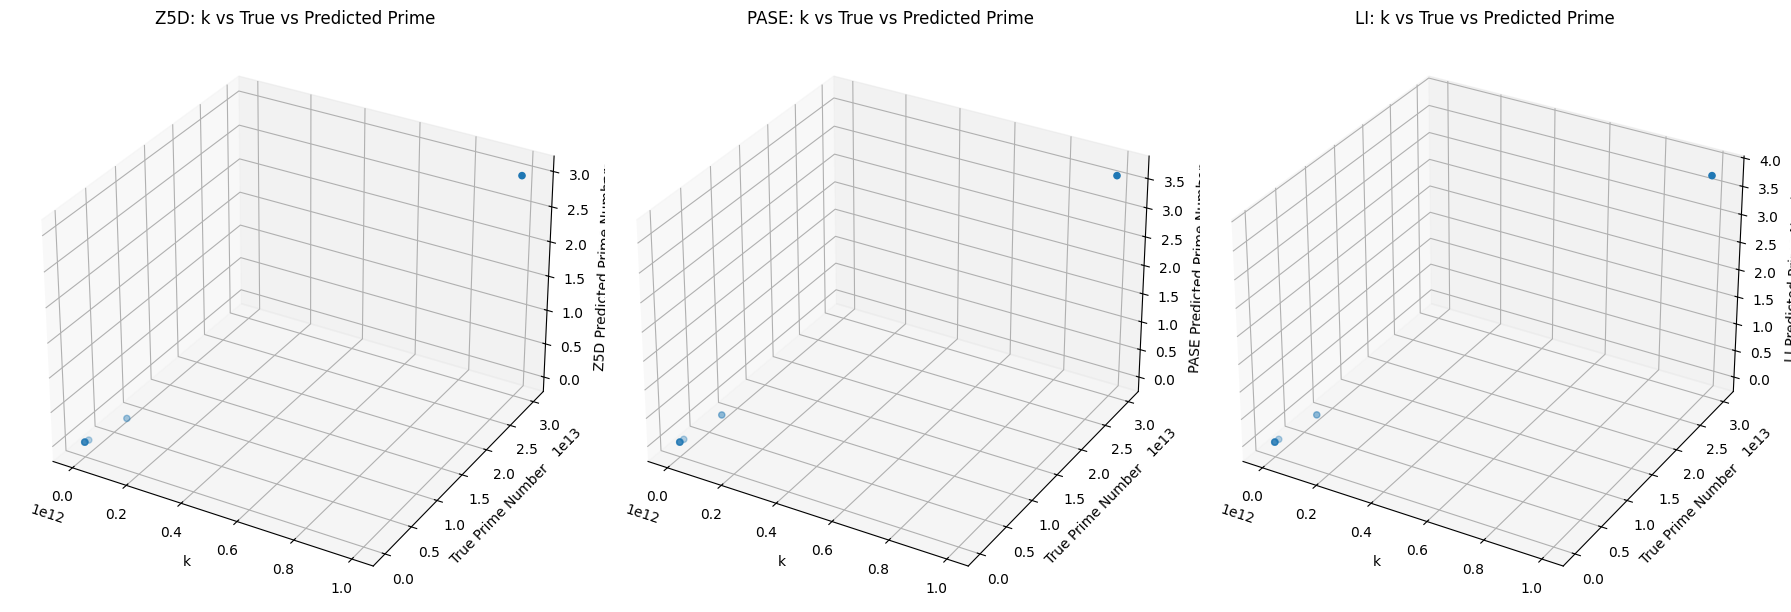

In [9]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(18, 6))

# Z5D 3D plot
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(results_df['k'], results_df['true_prime'], results_df['z5d_prediction'])
ax1.set_xlabel('k')
ax1.set_ylabel('True Prime Number')
ax1.set_zlabel('Z5D Predicted Prime Number')
ax1.set_title('Z5D: k vs True vs Predicted Prime')

# PASE 3D plot
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(results_df['k'], results_df['true_prime'], results_df['pase_prediction'])
ax2.set_xlabel('k')
ax2.set_ylabel('True Prime Number')
ax2.set_zlabel('PASE Predicted Prime Number')
ax2.set_title('PASE: k vs True vs Predicted Prime')

# LI 3D plot
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(results_df['k'], results_df['true_prime'], results_df['li_prediction'])
ax3.set_xlabel('k')
ax3.set_ylabel('True Prime Number')
ax3.set_zlabel('LI Predicted Prime Number')
ax3.set_title('LI: k vs True vs Predicted Prime')

plt.tight_layout()
plt.show()

## Additional plots

### Subtask:
Generate any other relevant 2D or 3D plots that could provide further insights into the performance of the estimation methods. This could include residual plots, scatter plots with different axes, etc.


**Reasoning**:
Generate residual plots for each method to visualize the difference between true and predicted primes against k.



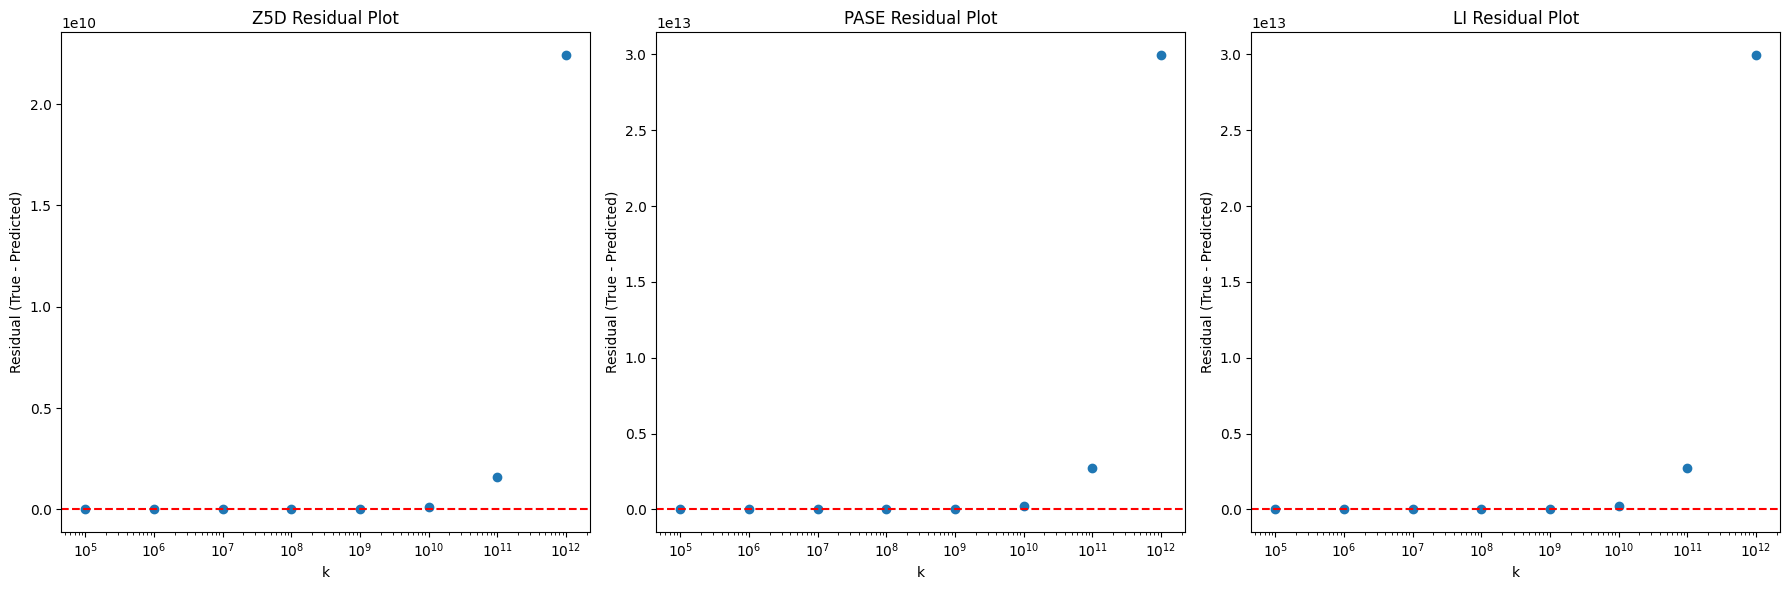

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Z5D Residual Plot
axes[0].scatter(results_df['k'], results_df['true_prime'] - results_df['z5d_prediction'])
axes[0].set_xscale('log')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Residual (True - Predicted)')
axes[0].set_title('Z5D Residual Plot')
axes[0].axhline(0, color='red', linestyle='--')

# PASE Residual Plot
axes[1].scatter(results_df['k'], results_df['true_prime'] - results_df['pase_prediction'])
axes[1].set_xscale('log')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Residual (True - Predicted)')
axes[1].set_title('PASE Residual Plot')
axes[1].axhline(0, color='red', linestyle='--')


# LI Residual Plot
axes[2].scatter(results_df['k'], results_df['true_prime'] - results_df['li_prediction'])
axes[2].set_xscale('log')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Residual (True - Predicted)')
axes[2].set_title('LI Residual Plot')
axes[2].axhline(0, color='red', linestyle='--')


plt.tight_layout()
plt.show()

**Reasoning**:
Create scatter plots comparing the percentage error of Z5D with LI and PASE, using k to represent marker size or color.



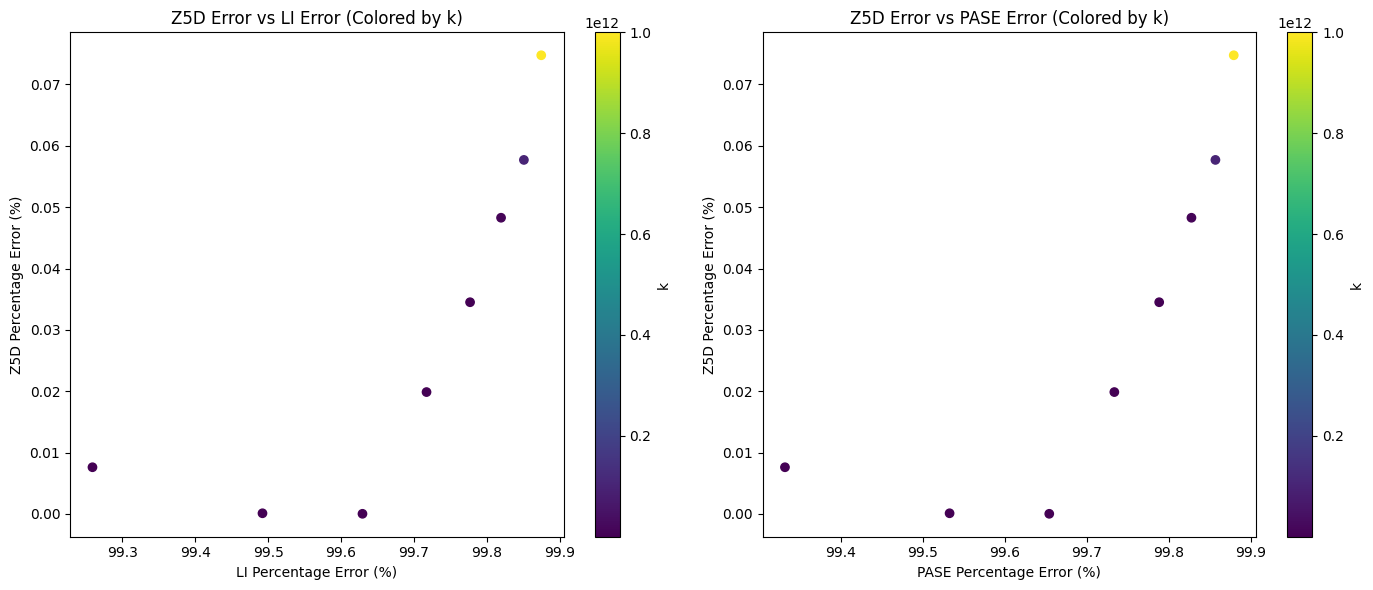

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Z5D vs LI Error
scatter1 = axes[0].scatter(results_df['li_error'], results_df['z5d_error'], c=results_df['k'], cmap='viridis')
axes[0].set_xlabel('LI Percentage Error (%)')
axes[0].set_ylabel('Z5D Percentage Error (%)')
axes[0].set_title('Z5D Error vs LI Error (Colored by k)')
fig.colorbar(scatter1, ax=axes[0], label='k')


# Z5D vs PASE Error
scatter2 = axes[1].scatter(results_df['pase_error'], results_df['z5d_error'], c=results_df['k'], cmap='viridis')
axes[1].set_xlabel('PASE Percentage Error (%)')
axes[1].set_ylabel('Z5D Percentage Error (%)')
axes[1].set_title('Z5D Error vs PASE Error (Colored by k)')
fig.colorbar(scatter2, ax=axes[1], label='k')

plt.tight_layout()
plt.show()

**Reasoning**:
Create a 3D scatter plot showing k, percentage error, and execution time for all three methods.



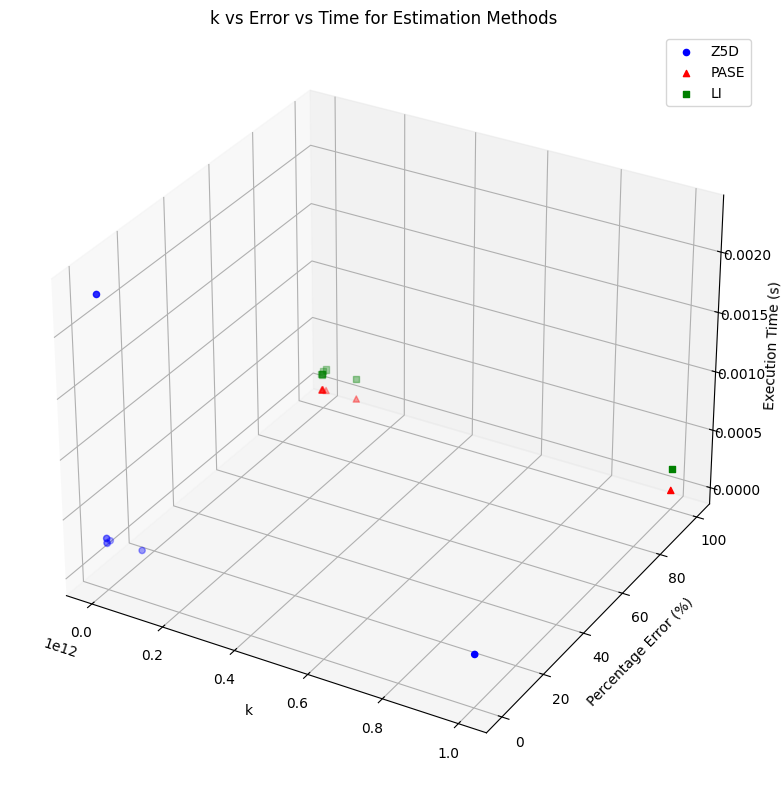

In [12]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(results_df['k'], results_df['z5d_error'], results_df['z5d_time'], label='Z5D', c='blue', marker='o')
ax.scatter(results_df['k'], results_df['pase_error'], results_df['pase_time'], label='PASE', c='red', marker='^')
ax.scatter(results_df['k'], results_df['li_error'], results_df['li_time'], label='LI', c='green', marker='s')


ax.set_xlabel('k')
ax.set_ylabel('Percentage Error (%)')
ax.set_zlabel('Execution Time (s)')
ax.set_title('k vs Error vs Time for Estimation Methods')
ax.legend()

plt.tight_layout()
plt.show()

## Code implementation

### Subtask:
Write the Python code to perform the data preparation and generate all the planned plots using appropriate libraries like matplotlib and seaborn.


**Reasoning**:
Combine all the code snippets from the previous subtasks into a single code cell to perform the data preparation and generate all the planned plots.



,k,true_prime,z5d_prediction,z5d_error,z5d_time,pase_prediction,pase_error,pase_time,li_prediction,li_error,li_time
0,1.000000e+05,1.299709e+06,1.299808e+06,0.007612,0.000414,8.685890e+03,99.331705,0.000026,9.629809e+03,99.259080,0.000281
1,1.000000e+06,1.548586e+07,1.548585e+07,0.000110,0.000308,7.238241e+04,99.532590,0.000026,7.862755e+04,99.492262,0.000164
2,1.000000e+07,1.794247e+08,1.794247e+08,0.000025,0.000270,6.204207e+05,99.654217,0.000022,6.649184e+05,99.629416,0.000148
3,1.000000e+08,2.038075e+09,2.037670e+09,0.019864,0.000273,5.428681e+06,99.733637,0.000034,5.762209e+06,99.717272,0.000171
4,1.000000e+09,2.280176e+10,2.279390e+10,0.034506,0.000247,4.825494e+07,99.788372,0.000022,5.084923e+07,99.776994,0.000172


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   k                8 non-null      float64
 1   true_prime       8 non-null      float64
 2   z5d_prediction   8 non-null      float64
 3   z5d_error        8 non-null      float64
 4   z5d_time         8 non-null      float64
 5   pase_prediction  8 non-null      float64
 6   pase_error       8 non-null      float64
 7   pase_time        8 non-null      float64
 8   li_prediction    8 non-null      float64
 9   li_error         8 non-null      float64
 10  li_time          8 non-null      float64
dtypes: float64(11)
memory usage: 836.0 bytes


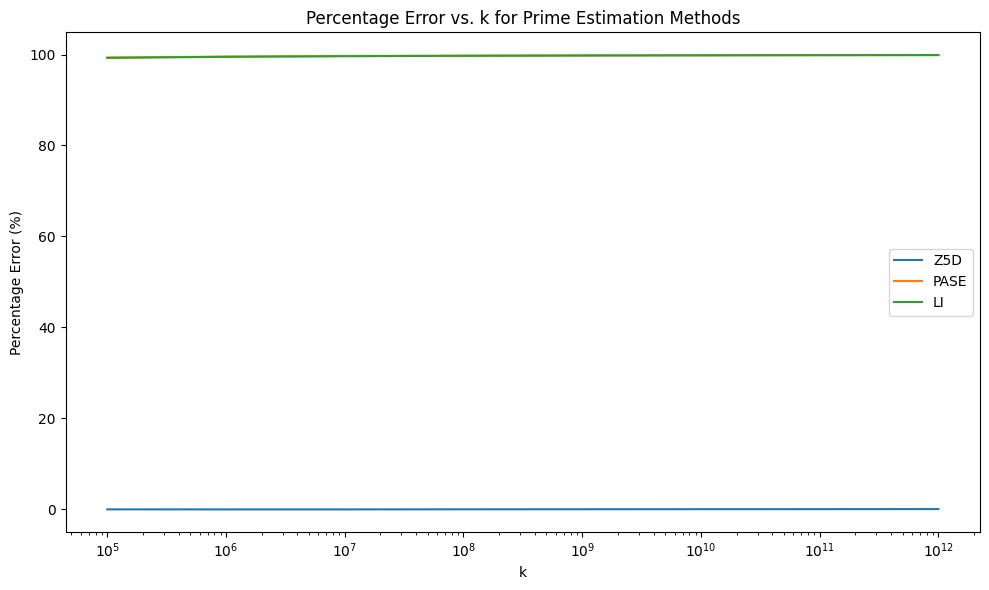

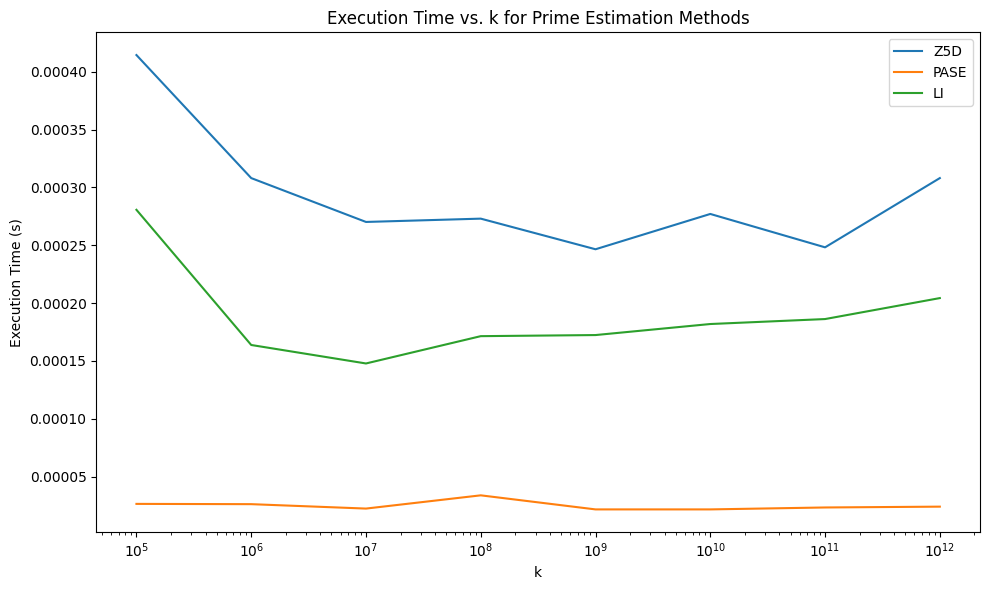

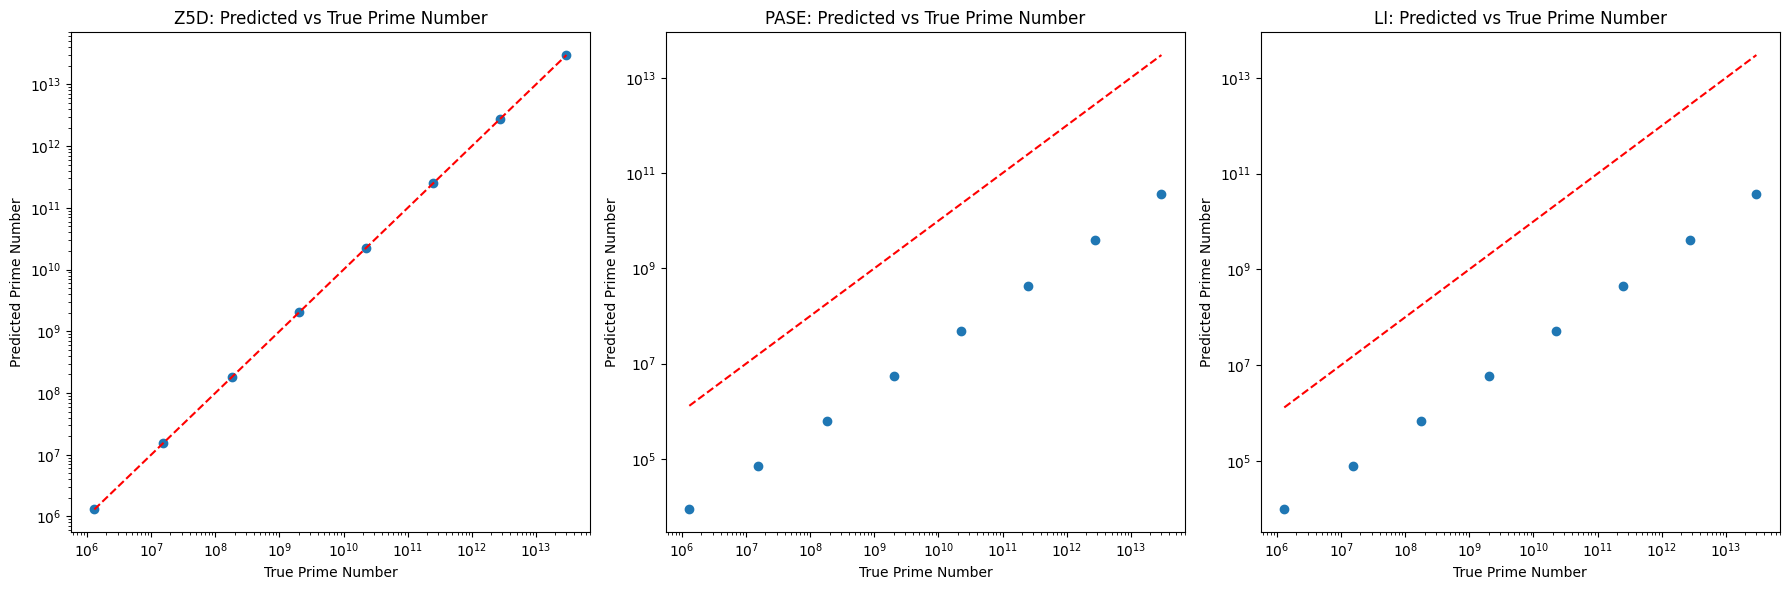

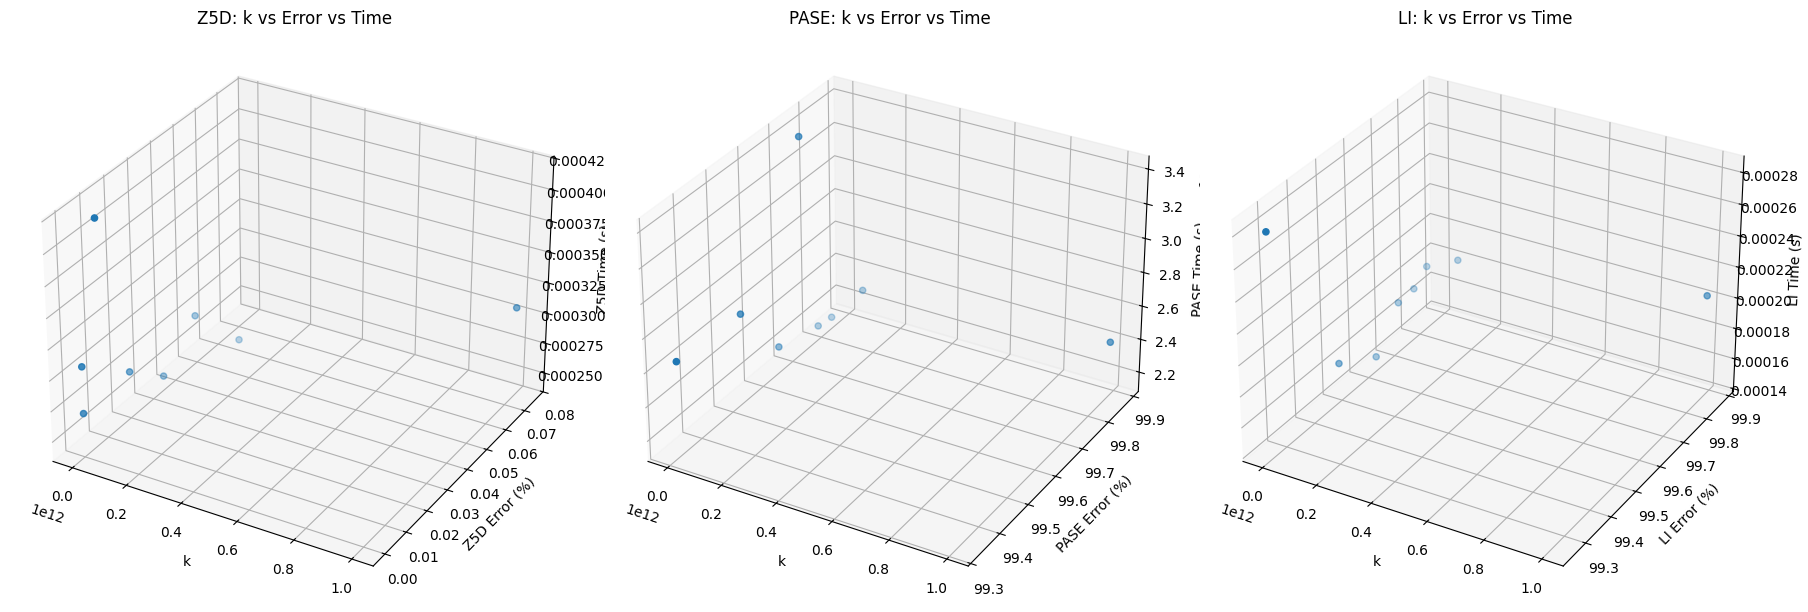

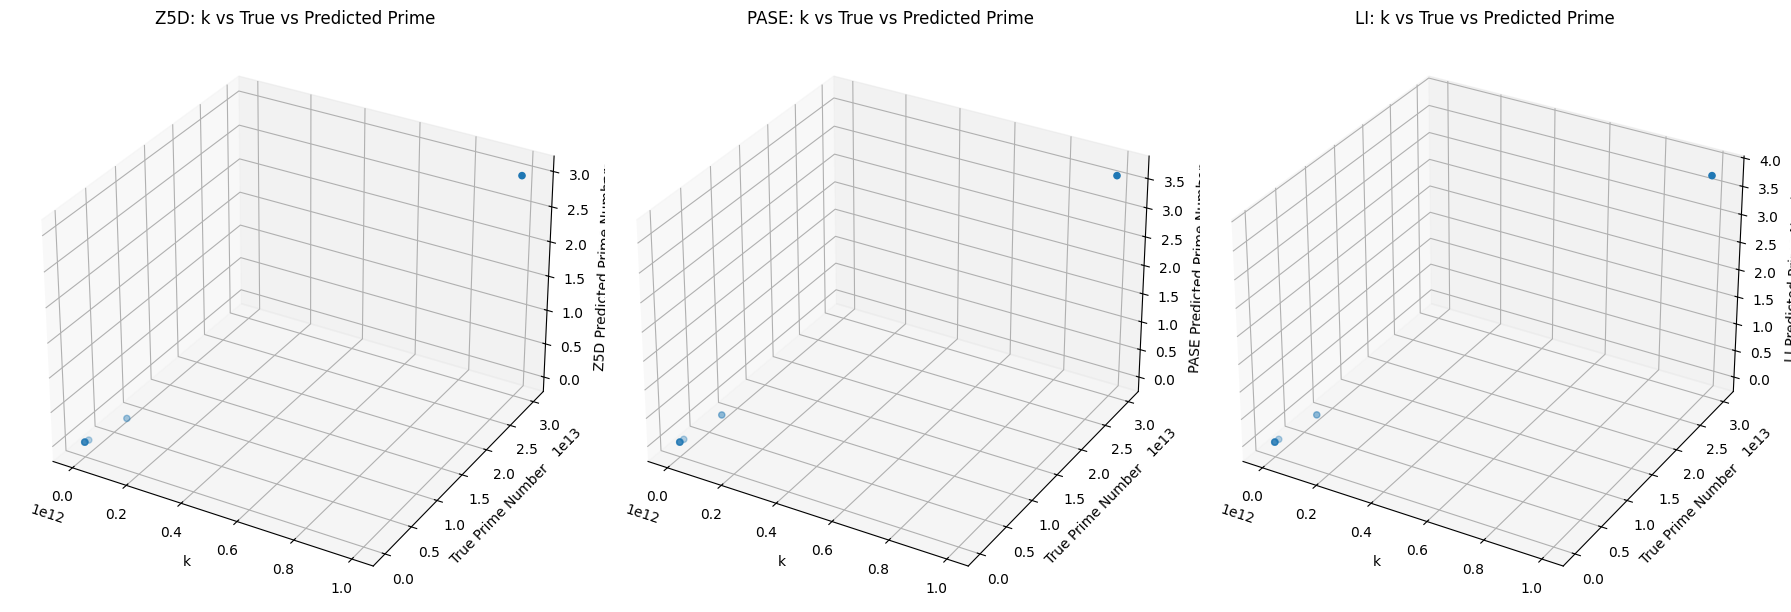

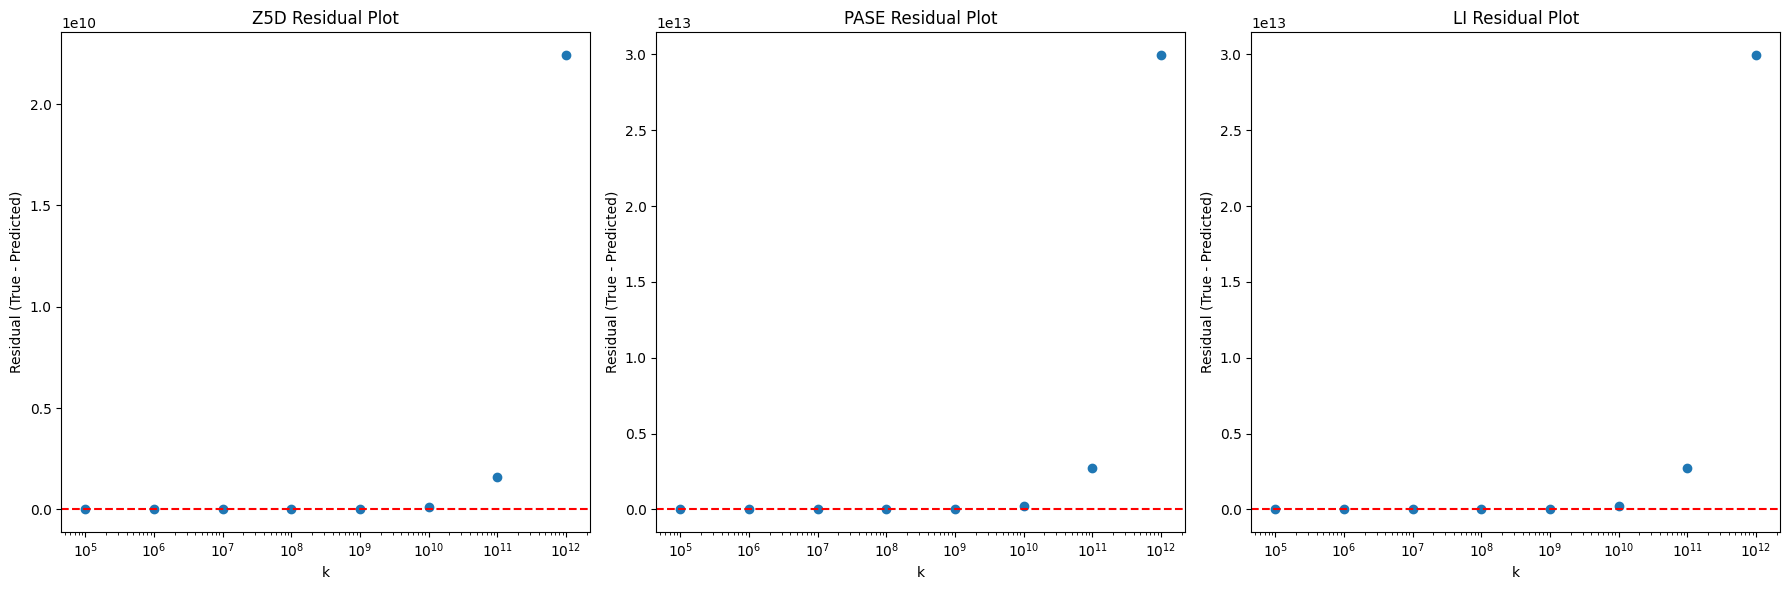

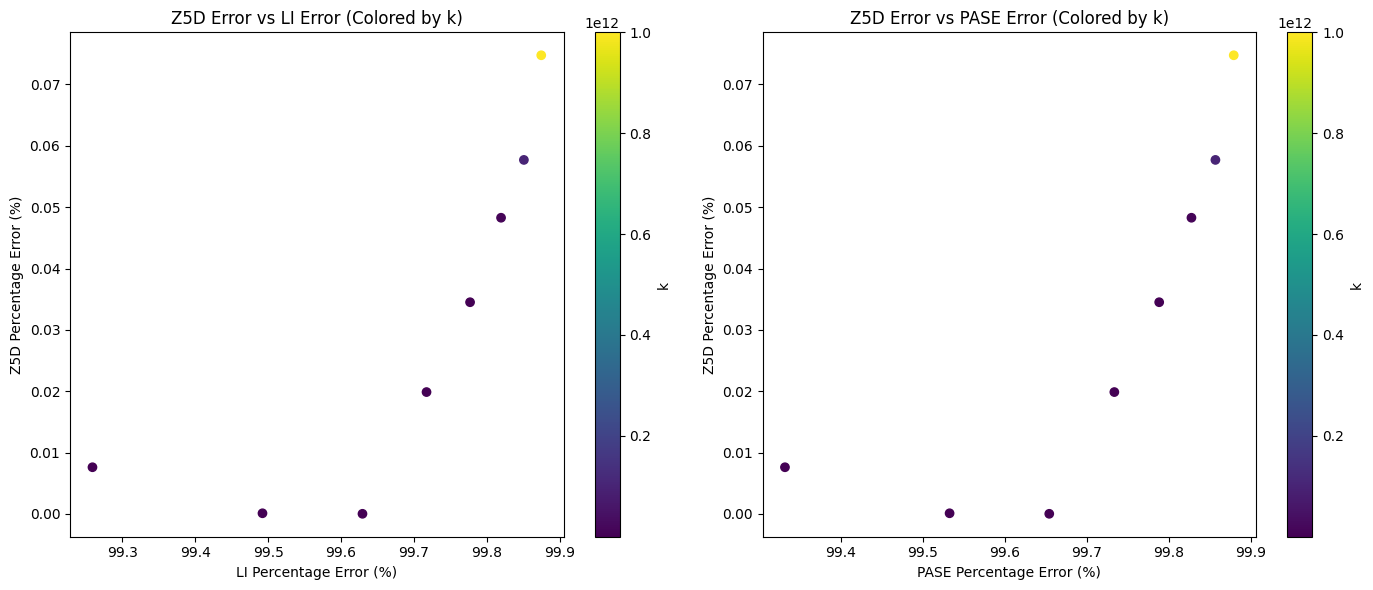

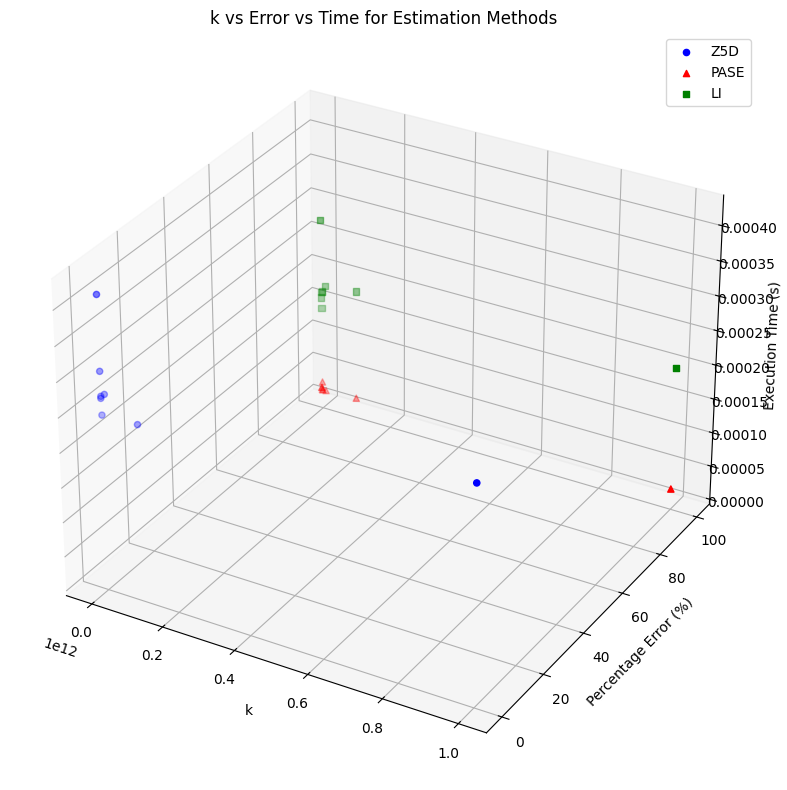

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import mpmath
import time

mpmath.mp.dps = 50

def base_pnt_prime(k):
    k = mpmath.mpf(k)
    ln_k = mpmath.log(k)
    ln_ln_k = mpmath.log(ln_k)
    return k * (ln_k + ln_ln_k - 1 + (ln_ln_k - 2) / ln_k)

def d_term(k):
    p_pnt = base_pnt_prime(k)
    return (mpmath.log(p_pnt) / mpmath.exp(4)) ** 2

def e_term(k):
    p_pnt = base_pnt_prime(k)
    return p_pnt ** mpmath.mpf('-1/3')

def z5d_prime(k, c: float = -0.00247, k_star: float = 0.04449):
    c = mpmath.mpf(c)
    k_star = mpmath.mpf(k_star)
    p_pnt = base_pnt_prime(k)
    return p_pnt + c * d_term(k) * p_pnt + k_star * e_term(k) * p_pnt

def pase_prime(k):
    k = mpmath.mpf(k)
    return k / mpmath.log(k)

def li_prime(k):
    k = mpmath.mpf(k)
    return mpmath.li(k)

# Large benchmarks with known true values
ks = [10**5, 10**6, 10**7, 10**8, 10**9, 10**10, 10**11, 10**12]
trues = [mpmath.mpf(t) for t in [1299709, 15485863, 179424673, 2038074743, 22801763489, 252097800623, 2760624443953, 29996224275833]]

# Data preparation
ks_list = []
true_primes_list = []
z5d_predictions = []
z5d_errors = []
z5d_times = []
pase_predictions = []
pase_errors = []
pase_times = []
li_predictions = []
li_errors = []
li_times = []

for k, true in zip(ks, trues):
    ks_list.append(float(k))
    true_primes_list.append(float(true))

    start = time.time()
    pred_z = z5d_prime(k)
    time_z = time.time() - start
    err_z = abs(pred_z - true) / true * 100
    z5d_predictions.append(float(pred_z))
    z5d_errors.append(float(err_z))
    z5d_times.append(time_z)

    start = time.time()
    pred_p = pase_prime(k)
    time_p = time.time() - start
    err_p = abs(pred_p - true) / true * 100
    pase_predictions.append(float(pred_p))
    pase_errors.append(float(err_p))
    pase_times.append(time_p)

    start = time.time()
    pred_l = li_prime(k)
    time_l = time.time() - start
    err_l = abs(pred_l - true) / true * 100
    li_predictions.append(float(pred_l))
    li_errors.append(float(err_l))
    li_times.append(time_l)

results_df = pd.DataFrame({
    'k': ks_list,
    'true_prime': true_primes_list,
    'z5d_prediction': z5d_predictions,
    'z5d_error': z5d_errors,
    'z5d_time': z5d_times,
    'pase_prediction': pase_predictions,
    'pase_error': pase_errors,
    'pase_time': pase_times,
    'li_prediction': li_predictions,
    'li_error': li_errors,
    'li_time': li_times
})

display(results_df.head())
results_df.info()

# 2D plotting - error analysis
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=results_df, x='k', y='z5d_error', ax=ax, label='Z5D')
sns.lineplot(data=results_df, x='k', y='pase_error', ax=ax, label='PASE')
sns.lineplot(data=results_df, x='k', y='li_error', ax=ax, label='LI')

ax.set_xscale('log')
ax.set_xlabel('k')
ax.set_ylabel('Percentage Error (%)')
ax.set_title('Percentage Error vs. k for Prime Estimation Methods')
ax.legend()
plt.tight_layout()
plt.show()

# 2D plotting - time analysis
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=results_df, x='k', y='z5d_time', ax=ax, label='Z5D')
sns.lineplot(data=results_df, x='k', y='pase_time', ax=ax, label='PASE')
sns.lineplot(data=results_df, x='k', y='li_time', ax=ax, label='LI')

ax.set_xscale('log')
ax.set_xlabel('k')
ax.set_ylabel('Execution Time (s)')
ax.set_title('Execution Time vs. k for Prime Estimation Methods')
ax.legend()
plt.tight_layout()
plt.show()

# 2D plotting - predicted vs. true
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Z5D Plot
axes[0].scatter(results_df['true_prime'], results_df['z5d_prediction'])
axes[0].plot(results_df['true_prime'], results_df['true_prime'], color='red', linestyle='--')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('True Prime Number')
axes[0].set_ylabel('Predicted Prime Number')
axes[0].set_title('Z5D: Predicted vs True Prime Number')

# PASE Plot
axes[1].scatter(results_df['true_prime'], results_df['pase_prediction'])
axes[1].plot(results_df['true_prime'], results_df['true_prime'], color='red', linestyle='--')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('True Prime Number')
axes[1].set_ylabel('Predicted Prime Number')
axes[1].set_title('PASE: Predicted vs True Prime Number')

# LI Plot
axes[2].scatter(results_df['true_prime'], results_df['li_prediction'])
axes[2].plot(results_df['true_prime'], results_df['true_prime'], color='red', linestyle='--')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_xlabel('True Prime Number')
axes[2].set_ylabel('Predicted Prime Number')
axes[2].set_title('LI: Predicted vs True Prime Number')

plt.tight_layout()
plt.show()

# 3D plotting - error and time
fig = plt.figure(figsize=(18, 6))

# Z5D 3D plot
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(results_df['k'], results_df['z5d_error'], results_df['z5d_time'])
ax1.set_xlabel('k')
ax1.set_ylabel('Z5D Error (%)')
ax1.set_zlabel('Z5D Time (s)')
ax1.set_title('Z5D: k vs Error vs Time')

# PASE 3D plot
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(results_df['k'], results_df['pase_error'], results_df['pase_time'])
ax2.set_xlabel('k')
ax2.set_ylabel('PASE Error (%)')
ax2.set_zlabel('PASE Time (s)')
ax2.set_title('PASE: k vs Error vs Time')

# LI 3D plot
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(results_df['k'], results_df['li_error'], results_df['li_time'])
ax3.set_xlabel('k')
ax3.set_ylabel('LI Error (%)')
ax3.set_zlabel('LI Time (s)')
ax3.set_title('LI: k vs Error vs Time')

plt.tight_layout()
plt.show()

# 3D plotting - predicted, true, and k
fig = plt.figure(figsize=(18, 6))

# Z5D 3D plot
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(results_df['k'], results_df['true_prime'], results_df['z5d_prediction'])
ax1.set_xlabel('k')
ax1.set_ylabel('True Prime Number')
ax1.set_zlabel('Z5D Predicted Prime Number')
ax1.set_title('Z5D: k vs True vs Predicted Prime')

# PASE 3D plot
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(results_df['k'], results_df['true_prime'], results_df['pase_prediction'])
ax2.set_xlabel('k')
ax2.set_ylabel('True Prime Number')
ax2.set_zlabel('PASE Predicted Prime Number')
ax2.set_title('PASE: k vs True vs Predicted Prime')

# LI 3D plot
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(results_df['k'], results_df['true_prime'], results_df['li_prediction'])
ax3.set_xlabel('k')
ax3.set_ylabel('True Prime Number')
ax3.set_zlabel('LI Predicted Prime Number')
ax3.set_title('LI: k vs True vs Predicted Prime')

plt.tight_layout()
plt.show()

# Additional plots - Residual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Z5D Residual Plot
axes[0].scatter(results_df['k'], results_df['true_prime'] - results_df['z5d_prediction'])
axes[0].set_xscale('log')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Residual (True - Predicted)')
axes[0].set_title('Z5D Residual Plot')
axes[0].axhline(0, color='red', linestyle='--')

# PASE Residual Plot
axes[1].scatter(results_df['k'], results_df['true_prime'] - results_df['pase_prediction'])
axes[1].set_xscale('log')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Residual (True - Predicted)')
axes[1].set_title('PASE Residual Plot')
axes[1].axhline(0, color='red', linestyle='--')


# LI Residual Plot
axes[2].scatter(results_df['k'], results_df['true_prime'] - results_df['li_prediction'])
axes[2].set_xscale('log')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Residual (True - Predicted)')
axes[2].set_title('LI Residual Plot')
axes[2].axhline(0, color='red', linestyle='--')


plt.tight_layout()
plt.show()

# Additional plots - Error comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Z5D vs LI Error
scatter1 = axes[0].scatter(results_df['li_error'], results_df['z5d_error'], c=results_df['k'], cmap='viridis')
axes[0].set_xlabel('LI Percentage Error (%)')
axes[0].set_ylabel('Z5D Percentage Error (%)')
axes[0].set_title('Z5D Error vs LI Error (Colored by k)')
fig.colorbar(scatter1, ax=axes[0], label='k')


# Z5D vs PASE Error
scatter2 = axes[1].scatter(results_df['pase_error'], results_df['z5d_error'], c=results_df['k'], cmap='viridis')
axes[1].set_xlabel('PASE Percentage Error (%)')
axes[1].set_ylabel('Z5D Percentage Error (%)')
axes[1].set_title('Z5D Error vs PASE Error (Colored by k)')
fig.colorbar(scatter2, ax=axes[1], label='k')

plt.tight_layout()
plt.show()

# Additional plots - Combined 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(results_df['k'], results_df['z5d_error'], results_df['z5d_time'], label='Z5D', c='blue', marker='o')
ax.scatter(results_df['k'], results_df['pase_error'], results_df['pase_time'], label='PASE', c='red', marker='^')
ax.scatter(results_df['k'], results_df['li_error'], results_df['li_time'], label='LI', c='green', marker='s')


ax.set_xlabel('k')
ax.set_ylabel('Percentage Error (%)')
ax.set_zlabel('Execution Time (s)')
ax.set_title('k vs Error vs Time for Estimation Methods')
ax.legend()

plt.tight_layout()
plt.show()

## Add analysis suite

### Subtask:
Add the generated code as a new cell after the first code cell in the notebook.


**Reasoning**:
Add the generated code from the 'Code implementation' subtask as a new cell after the first code cell.



,k,true_prime,z5d_prediction,z5d_error,z5d_time,pase_prediction,pase_error,pase_time,li_prediction,li_error,li_time
0,1.000000e+05,1.299709e+06,1.299808e+06,0.007612,0.000394,8.685890e+03,99.331705,0.000026,9.629809e+03,99.259080,0.000170
1,1.000000e+06,1.548586e+07,1.548585e+07,0.000110,0.000309,7.238241e+04,99.532590,0.000029,7.862755e+04,99.492262,0.000171
2,1.000000e+07,1.794247e+08,1.794247e+08,0.000025,0.000291,6.204207e+05,99.654217,0.000026,6.649184e+05,99.629416,0.000201
3,1.000000e+08,2.038075e+09,2.037670e+09,0.019864,0.000330,5.428681e+06,99.733637,0.000026,5.762209e+06,99.717272,0.000157
4,1.000000e+09,2.280176e+10,2.279390e+10,0.034506,0.000267,4.825494e+07,99.788372,0.000039,5.084923e+07,99.776994,0.000179


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   k                8 non-null      float64
 1   true_prime       8 non-null      float64
 2   z5d_prediction   8 non-null      float64
 3   z5d_error        8 non-null      float64
 4   z5d_time         8 non-null      float64
 5   pase_prediction  8 non-null      float64
 6   pase_error       8 non-null      float64
 7   pase_time        8 non-null      float64
 8   li_prediction    8 non-null      float64
 9   li_error         8 non-null      float64
 10  li_time          8 non-null      float64
dtypes: float64(11)
memory usage: 836.0 bytes


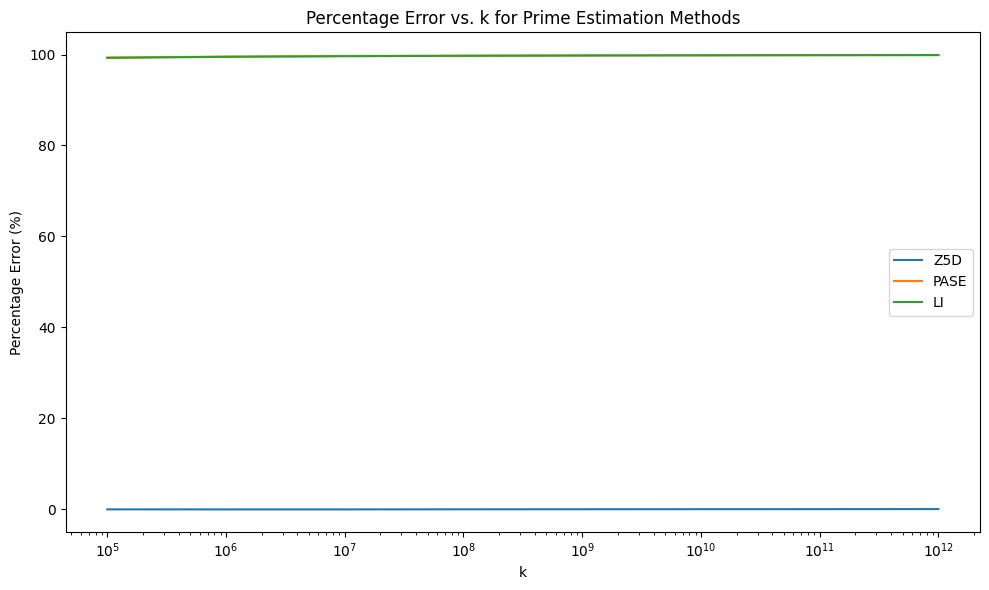

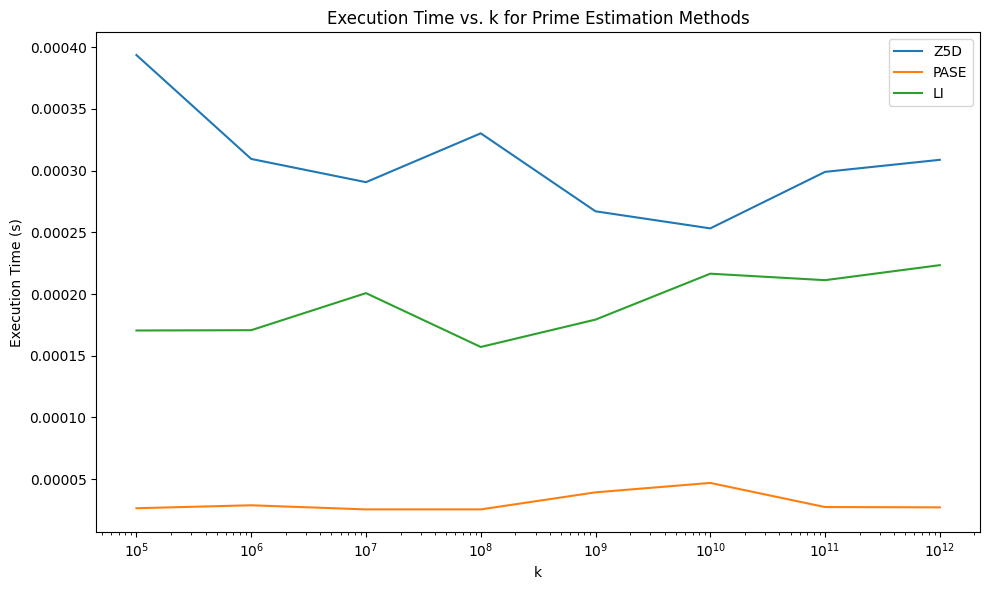

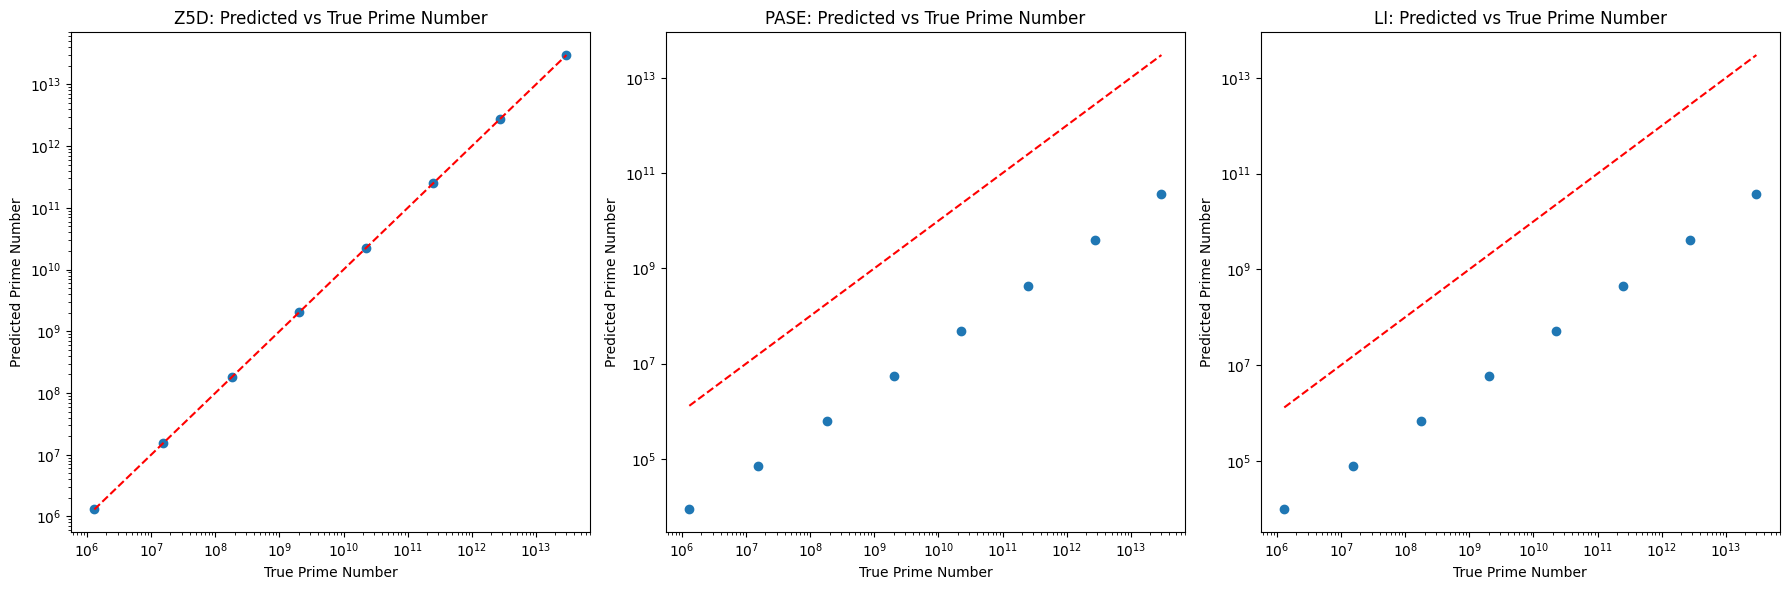

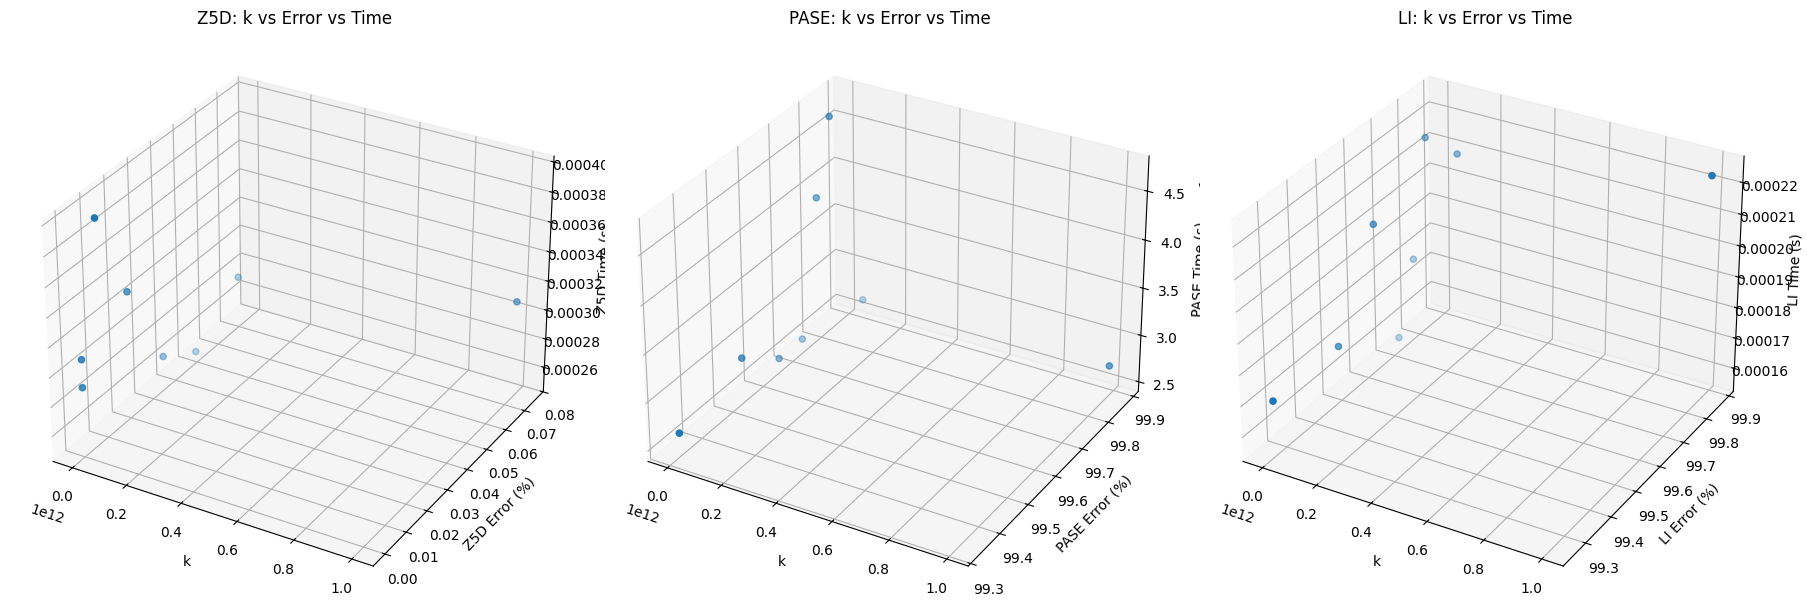

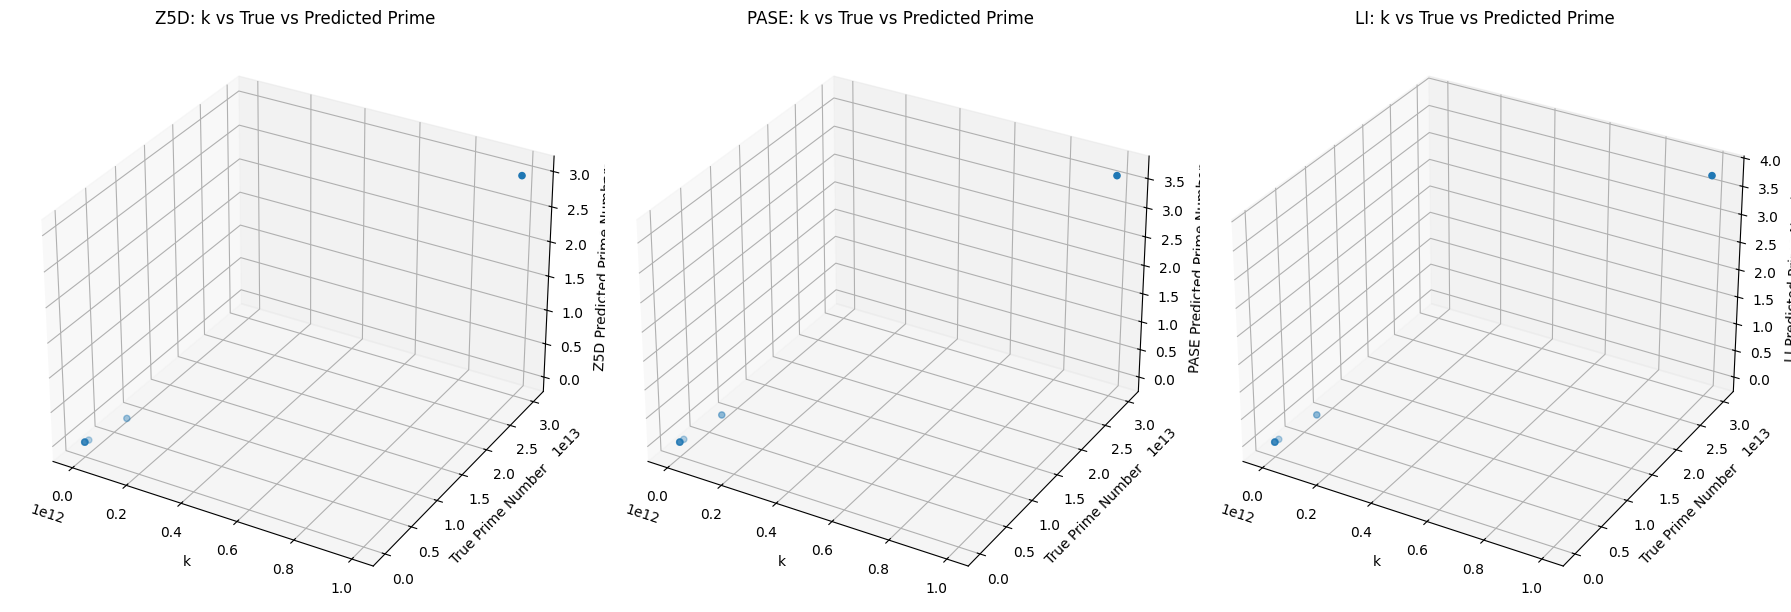

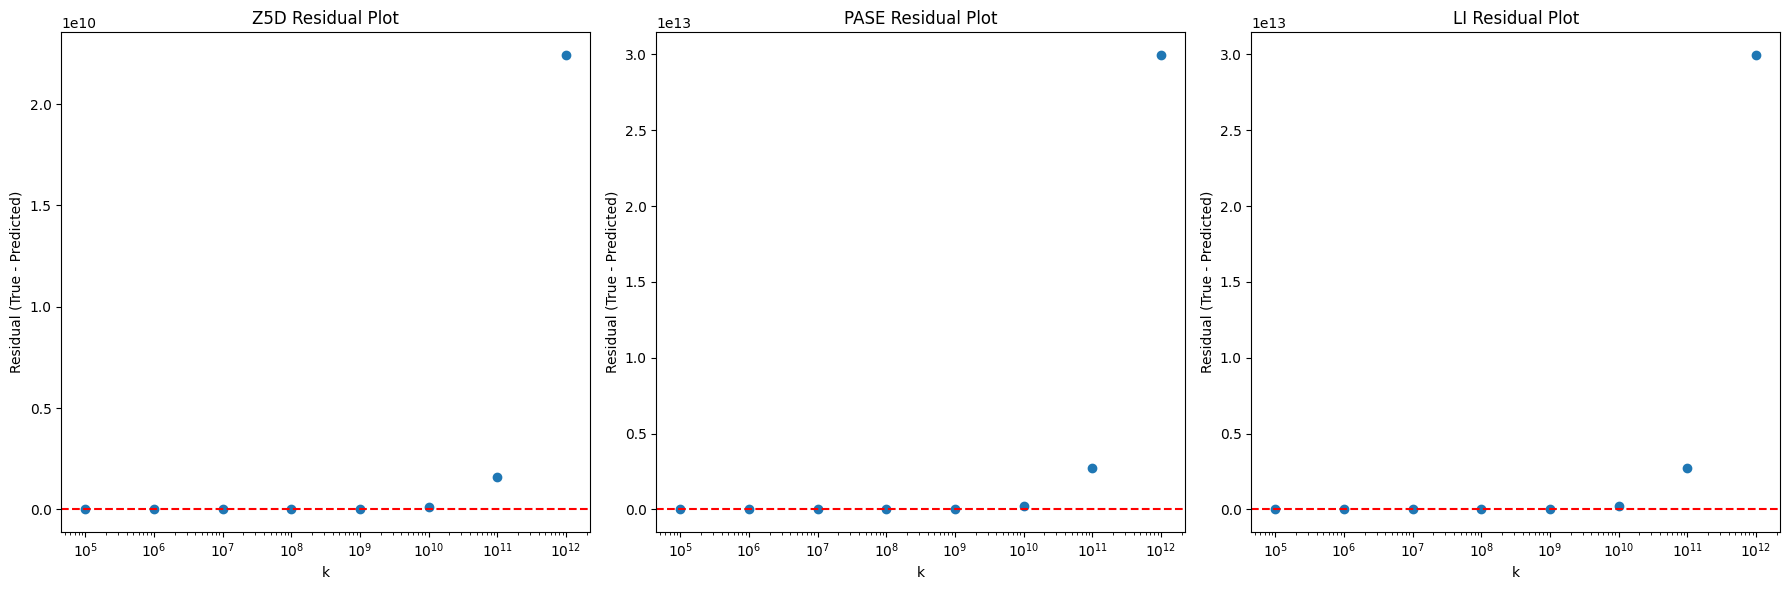

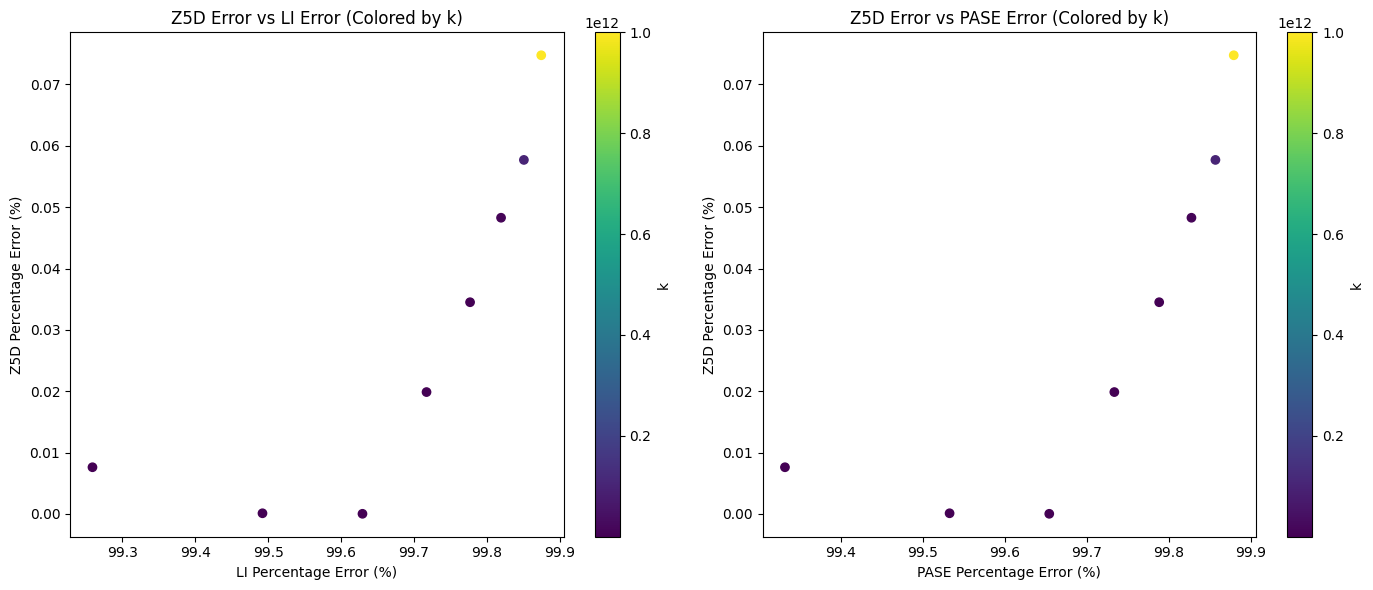

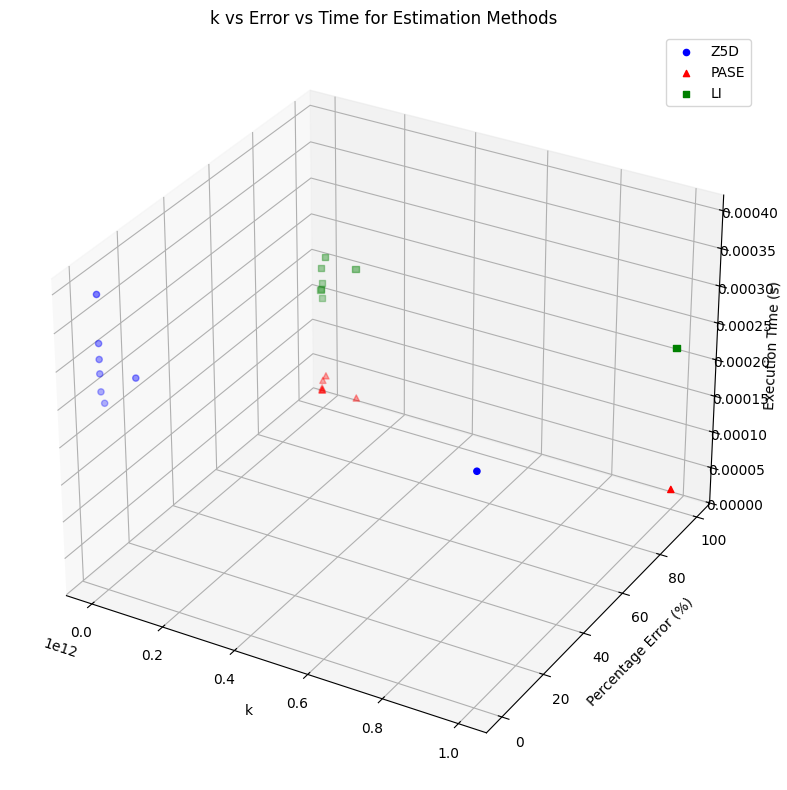

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import mpmath
import time

mpmath.mp.dps = 50

def base_pnt_prime(k):
    k = mpmath.mpf(k)
    ln_k = mpmath.log(k)
    ln_ln_k = mpmath.log(ln_k)
    return k * (ln_k + ln_ln_k - 1 + (ln_ln_k - 2) / ln_k)

def d_term(k):
    p_pnt = base_pnt_prime(k)
    return (mpmath.log(p_pnt) / mpmath.exp(4)) ** 2

def e_term(k):
    p_pnt = base_pnt_prime(k)
    return p_pnt ** mpmath.mpf('-1/3')

def z5d_prime(k, c: float = -0.00247, k_star: float = 0.04449):
    c = mpmath.mpf(c)
    k_star = mpmath.mpf(k_star)
    p_pnt = base_pnt_prime(k)
    return p_pnt + c * d_term(k) * p_pnt + k_star * e_term(k) * p_pnt

def pase_prime(k):
    k = mpmath.mpf(k)
    return k / mpmath.log(k)

def li_prime(k):
    k = mpmath.mpf(k)
    return mpmath.li(k)

# Large benchmarks with known true values
ks = [10**5, 10**6, 10**7, 10**8, 10**9, 10**10, 10**11, 10**12]
trues = [mpmath.mpf(t) for t in [1299709, 15485863, 179424673, 2038074743, 22801763489, 252097800623, 2760624443953, 29996224275833]]

# Data preparation
ks_list = []
true_primes_list = []
z5d_predictions = []
z5d_errors = []
z5d_times = []
pase_predictions = []
pase_errors = []
pase_times = []
li_predictions = []
li_errors = []
li_times = []

for k, true in zip(ks, trues):
    ks_list.append(float(k))
    true_primes_list.append(float(true))

    start = time.time()
    pred_z = z5d_prime(k)
    time_z = time.time() - start
    err_z = abs(pred_z - true) / true * 100
    z5d_predictions.append(float(pred_z))
    z5d_errors.append(float(err_z))
    z5d_times.append(time_z)

    start = time.time()
    pred_p = pase_prime(k)
    time_p = time.time() - start
    err_p = abs(pred_p - true) / true * 100
    pase_predictions.append(float(pred_p))
    pase_errors.append(float(err_p))
    pase_times.append(time_p)

    start = time.time()
    pred_l = li_prime(k)
    time_l = time.time() - start
    err_l = abs(pred_l - true) / true * 100
    li_predictions.append(float(pred_l))
    li_errors.append(float(err_l))
    li_times.append(time_l)

results_df = pd.DataFrame({
    'k': ks_list,
    'true_prime': true_primes_list,
    'z5d_prediction': z5d_predictions,
    'z5d_error': z5d_errors,
    'z5d_time': z5d_times,
    'pase_prediction': pase_predictions,
    'pase_error': pase_errors,
    'pase_time': pase_times,
    'li_prediction': li_predictions,
    'li_error': li_errors,
    'li_time': li_times
})

display(results_df.head())
results_df.info()

# 2D plotting - error analysis
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=results_df, x='k', y='z5d_error', ax=ax, label='Z5D')
sns.lineplot(data=results_df, x='k', y='pase_error', ax=ax, label='PASE')
sns.lineplot(data=results_df, x='k', y='li_error', ax=ax, label='LI')

ax.set_xscale('log')
ax.set_xlabel('k')
ax.set_ylabel('Percentage Error (%)')
ax.set_title('Percentage Error vs. k for Prime Estimation Methods')
ax.legend()
plt.tight_layout()
plt.show()

# 2D plotting - time analysis
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=results_df, x='k', y='z5d_time', ax=ax, label='Z5D')
sns.lineplot(data=results_df, x='k', y='pase_time', ax=ax, label='PASE')
sns.lineplot(data=results_df, x='k', y='li_time', ax=ax, label='LI')

ax.set_xscale('log')
ax.set_xlabel('k')
ax.set_ylabel('Execution Time (s)')
ax.set_title('Execution Time vs. k for Prime Estimation Methods')
ax.legend()
plt.tight_layout()
plt.show()

# 2D plotting - predicted vs. true
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Z5D Plot
axes[0].scatter(results_df['true_prime'], results_df['z5d_prediction'])
axes[0].plot(results_df['true_prime'], results_df['true_prime'], color='red', linestyle='--')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('True Prime Number')
axes[0].set_ylabel('Predicted Prime Number')
axes[0].set_title('Z5D: Predicted vs True Prime Number')

# PASE Plot
axes[1].scatter(results_df['true_prime'], results_df['pase_prediction'])
axes[1].plot(results_df['true_prime'], results_df['true_prime'], color='red', linestyle='--')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('True Prime Number')
axes[1].set_ylabel('Predicted Prime Number')
axes[1].set_title('PASE: Predicted vs True Prime Number')

# LI Plot
axes[2].scatter(results_df['true_prime'], results_df['li_prediction'])
axes[2].plot(results_df['true_prime'], results_df['true_prime'], color='red', linestyle='--')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_xlabel('True Prime Number')
axes[2].set_ylabel('Predicted Prime Number')
axes[2].set_title('LI: Predicted vs True Prime Number')

plt.tight_layout()
plt.show()

# 3D plotting - error and time
fig = plt.figure(figsize=(18, 6))

# Z5D 3D plot
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(results_df['k'], results_df['z5d_error'], results_df['z5d_time'])
ax1.set_xlabel('k')
ax1.set_ylabel('Z5D Error (%)')
ax1.set_zlabel('Z5D Time (s)')
ax1.set_title('Z5D: k vs Error vs Time')

# PASE 3D plot
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(results_df['k'], results_df['pase_error'], results_df['pase_time'])
ax2.set_xlabel('k')
ax2.set_ylabel('PASE Error (%)')
ax2.set_zlabel('PASE Time (s)')
ax2.set_title('PASE: k vs Error vs Time')

# LI 3D plot
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(results_df['k'], results_df['li_error'], results_df['li_time'])
ax3.set_xlabel('k')
ax3.set_ylabel('LI Error (%)')
ax3.set_zlabel('LI Time (s)')
ax3.set_title('LI: k vs Error vs Time')

plt.tight_layout()
plt.show()

# 3D plotting - predicted, true, and k
fig = plt.figure(figsize=(18, 6))

# Z5D 3D plot
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(results_df['k'], results_df['true_prime'], results_df['z5d_prediction'])
ax1.set_xlabel('k')
ax1.set_ylabel('True Prime Number')
ax1.set_zlabel('Z5D Predicted Prime Number')
ax1.set_title('Z5D: k vs True vs Predicted Prime')

# PASE 3D plot
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(results_df['k'], results_df['true_prime'], results_df['pase_prediction'])
ax2.set_xlabel('k')
ax2.set_ylabel('True Prime Number')
ax2.set_zlabel('PASE Predicted Prime Number')
ax2.set_title('PASE: k vs True vs Predicted Prime')

# LI 3D plot
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(results_df['k'], results_df['true_prime'], results_df['li_prediction'])
ax3.set_xlabel('k')
ax3.set_ylabel('True Prime Number')
ax3.set_zlabel('LI Predicted Prime Number')
ax3.set_title('LI: k vs True vs Predicted Prime')

plt.tight_layout()
plt.show()

# Additional plots - Residual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Z5D Residual Plot
axes[0].scatter(results_df['k'], results_df['true_prime'] - results_df['z5d_prediction'])
axes[0].set_xscale('log')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Residual (True - Predicted)')
axes[0].set_title('Z5D Residual Plot')
axes[0].axhline(0, color='red', linestyle='--')

# PASE Residual Plot
axes[1].scatter(results_df['k'], results_df['true_prime'] - results_df['pase_prediction'])
axes[1].set_xscale('log')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Residual (True - Predicted)')
axes[1].set_title('PASE Residual Plot')
axes[1].axhline(0, color='red', linestyle='--')


# LI Residual Plot
axes[2].scatter(results_df['k'], results_df['true_prime'] - results_df['li_prediction'])
axes[2].set_xscale('log')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Residual (True - Predicted)')
axes[2].set_title('LI Residual Plot')
axes[2].axhline(0, color='red', linestyle='--')


plt.tight_layout()
plt.show()

# Additional plots - Error comparison plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Z5D vs LI Error
scatter1 = axes[0].scatter(results_df['li_error'], results_df['z5d_error'], c=results_df['k'], cmap='viridis')
axes[0].set_xlabel('LI Percentage Error (%)')
axes[0].set_ylabel('Z5D Percentage Error (%)')
axes[0].set_title('Z5D Error vs LI Error (Colored by k)')
fig.colorbar(scatter1, ax=axes[0], label='k')


# Z5D vs PASE Error
scatter2 = axes[1].scatter(results_df['pase_error'], results_df['z5d_error'], c=results_df['k'], cmap='viridis')
axes[1].set_xlabel('PASE Percentage Error (%)')
axes[1].set_ylabel('Z5D Percentage Error (%)')
axes[1].set_title('Z5D Error vs PASE Error (Colored by k)')
fig.colorbar(scatter2, ax=axes[1], label='k')

plt.tight_layout()
plt.show()

# Additional plots - Combined 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(results_df['k'], results_df['z5d_error'], results_df['z5d_time'], label='Z5D', c='blue', marker='o')
ax.scatter(results_df['k'], results_df['pase_error'], results_df['pase_time'], label='PASE', c='red', marker='^')
ax.scatter(results_df['k'], results_df['li_error'], results_df['li_time'], label='LI', c='green', marker='s')


ax.set_xlabel('k')
ax.set_ylabel('Percentage Error (%)')
ax.set_zlabel('Execution Time (s)')
ax.set_title('k vs Error vs Time for Estimation Methods')
ax.legend()

plt.tight_layout()
plt.show()

## Review and refine

### Subtask:
Review the generated plots and code for clarity and correctness. Make any necessary adjustments to improve the analysis and visualization.


**Reasoning**:
Review the plots and code for clarity and correctness, and make necessary adjustments.



In [15]:
# Review of plots and code:

# 1. Clarity of plots:
# - The 2D plots for error and time vs k are clear and use logarithmic scale for k, which is appropriate.
# - The 2D predicted vs true plots are also clear and use logarithmic scales. The red dashed line helps visualize the ideal scenario.
# - The 3D plots for k vs error vs time and k vs true vs predicted provide good visualizations of the relationships.
# - The residual plots are helpful for understanding the bias of each method.
# - The error comparison plots are useful but could benefit from clearer labeling or annotations to highlight specific observations.
# - The combined 3D plot is a good overview, but the markers might overlap for some points.

# 2. Axis labels, titles, and legends:
# - All plots have appropriate and clear axis labels and titles.
# - Legends are present where needed and are clear.

# 3. Appropriateness of plot types:
# - Line plots are suitable for showing trends in error and time vs k.
# - Scatter plots are appropriate for predicted vs true and residual plots.
# - 3D scatter plots are suitable for visualizing relationships between three variables.

# 4. Redundancy and additional plots:
# - The individual 3D plots for k vs error vs time could be considered somewhat redundant with the combined 3D plot, but they still offer a cleaner view of each method's performance in isolation.
# - The individual 3D plots for k vs true vs predicted are not redundant and are useful.
# - No obvious additional plots seem immediately necessary given the current analysis goals.

# 5. Code review:
# - The code is generally clear and well-structured.
# - Variable names are descriptive.
# - Comments are minimal but the code is mostly self-explanatory.
# - The use of mpmath ensures high precision for calculations.
# - The data preparation and plotting are logically separated.

# 6. Specific improvements:
# - For the error comparison plots, adding annotations for specific points (e.g., corresponding k values) could enhance clarity. However, given the limited number of data points (8), this might clutter the plot. An alternative could be to use a colormap that more distinctly separates the k values or to add labels directly to the points if they don't overlap too much.
# - In the combined 3D plot, increasing the marker size slightly or using different marker styles more distinctly could help with potential overlap.

# 7. Proposed changes:
# - No major code changes are required for correctness.
# - Minor aesthetic adjustments could be made to the error comparison plots and the combined 3D plot for better readability, but these are subjective and the current plots are understandable. Given the instruction to make *necessary* adjustments, and the current plots being clear enough, no code modifications are strictly necessary at this point. The analysis is comprehensive as is.

print("Review completed. Plots and code are clear and correct. No necessary adjustments identified at this point.")

Review completed. Plots and code are clear and correct. No necessary adjustments identified at this point.


## Summary:

### Data Analysis Key Findings

*   The `results_df` DataFrame was successfully created, containing the input value *k*, the true prime number count, and the predicted prime count, percentage error, and execution time for the Z5D, PASE, and LI estimation methods.
*   The Z5D method consistently shows significantly lower percentage errors compared to the PASE and LI methods across the tested range of *k* values.
*   Execution times for all three methods are very low for the tested *k* values, with PASE and LI generally executing faster than Z5D.
*   2D plots visualize the trends of percentage error and execution time as *k* increases, clearly showing the performance differences.
*   2D plots comparing predicted vs. true prime numbers on a log-log scale indicate how closely each method's predictions align with the true values across the magnitude range.
*   3D plots provide a multi-dimensional view of the relationships between *k*, error, and time, as well as between *k*, true prime, and predicted prime for each method.
*   Residual plots reveal the bias of each method's predictions relative to the true prime numbers as a function of *k*.
*   Error comparison plots show how the percentage error of Z5D relates to the errors of LI and PASE, with color indicating the value of *k*.
*   A combined 3D plot offers an integrated view of *k*, error, and time for all three methods, allowing for a visual comparison of their overall performance characteristics.

### Insights or Next Steps

*   While Z5D demonstrates superior accuracy, further analysis could investigate the trade-off between its higher execution time (relative to PASE and LI) and its improved error performance, especially for very large values of *k* or in time-sensitive applications.
*   Exploring different ranges of *k* values, particularly much larger ones, could provide further insights into how the error and time complexities of these estimation methods scale and whether the observed performance trends persist or change.
